In [1]:
import importlib.util
import sys
from pathlib import Path
custom_rqa_path = Path("/home/idies/workspace/RQA-and-mrDMD") / "CustomRQA.py"

spec = importlib.util.spec_from_file_location("CustomRQA", str(custom_rqa_path))

CustomRQA = importlib.util.module_from_spec(spec)

spec.loader.exec_module(CustomRQA)

sys.modules["CustomRQA"] = CustomRQA



truncate_path = Path("/home/idies/workspace/RQA-and-mrDMD") / "truncate.py"

spec = importlib.util.spec_from_file_location("truncate", str(truncate_path))

truncate = importlib.util.module_from_spec(spec)

spec.loader.exec_module(truncate)

sys.modules["truncate"] = truncate

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
%pip install pydmd
%pip install statsmodels
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.plotter import plot_eigs, plot_summary
from pydmd.preprocessing import hankel_preprocessing
import warnings
warnings.filterwarnings('ignore')
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import CustomRQA as rqa
import truncate as tr

url = '/home/idies/workspace/RQA-and-mrDMD/Turbulence/Data/mixingdata2187.npy'
x = np.load(url)
total_t = 40.44
n_tgt = 1012
dt = total_t / (n_tgt - 1)
t = np.linspace(0, total_t, n_tgt)
print(dt, t)
X = StandardScaler().fit_transform(x)
print(X.shape)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
0.04 [0.000e+00 4.000e-02 8.000e-02 ... 4.036e+01 4.040e+01 4.044e+01]
(2187, 1012)


In [3]:
print(X.shape)
sub_dmd = DMD(svd_rank=0.75)
l=8
mrdmd = MrDMD(sub_dmd, max_level=l, max_cycles=1)
mrdmd.fit(X)


(2187, 1012)


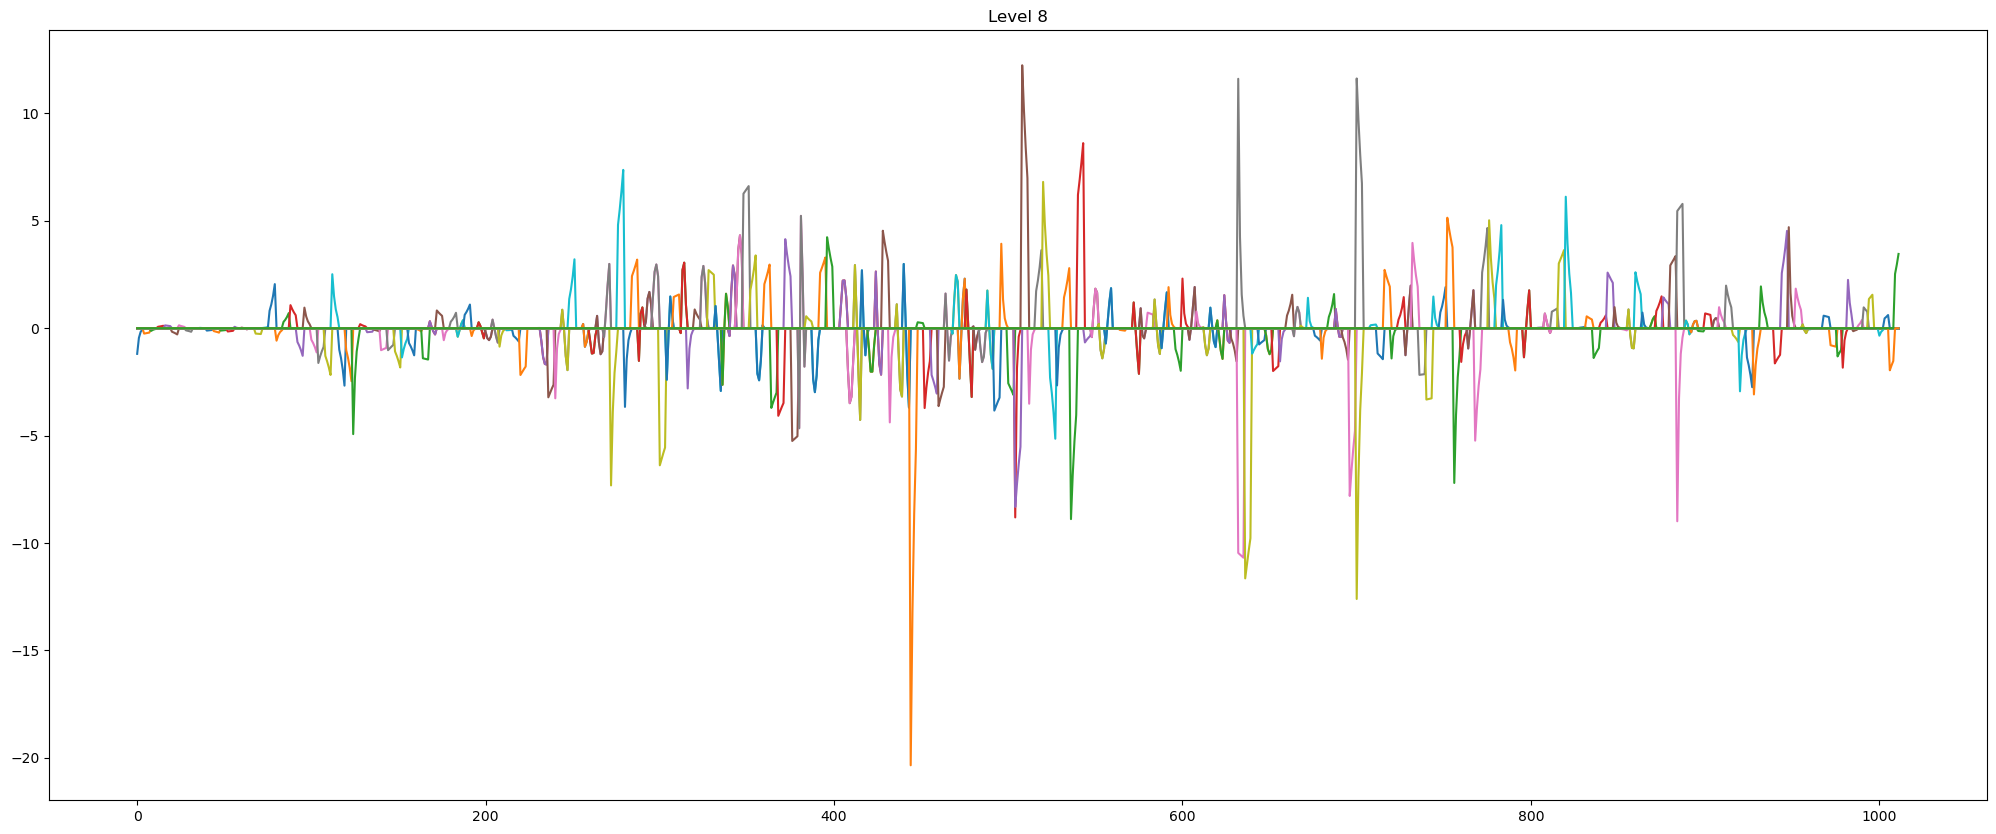

(313, 1012)
(1012, 247)


In [4]:
last_dynamics = mrdmd.partial_dynamics(level=l)
#last_dynamics = StandardScaler().fit_transform(last_dynamics.real)
plt.figure(figsize=(25,10))
for i in range(last_dynamics.shape[0]):
    plt.plot(last_dynamics[i])
plt.title(f'Level 8')
plt.show()
print(last_dynamics.shape)
df_dynamics = tr.correlation_truncate(last_dynamics.T, threshold =0.80)
all_vectors_new = df_dynamics.to_numpy()
all_vectors = all_vectors_new
print(all_vectors_new.shape)

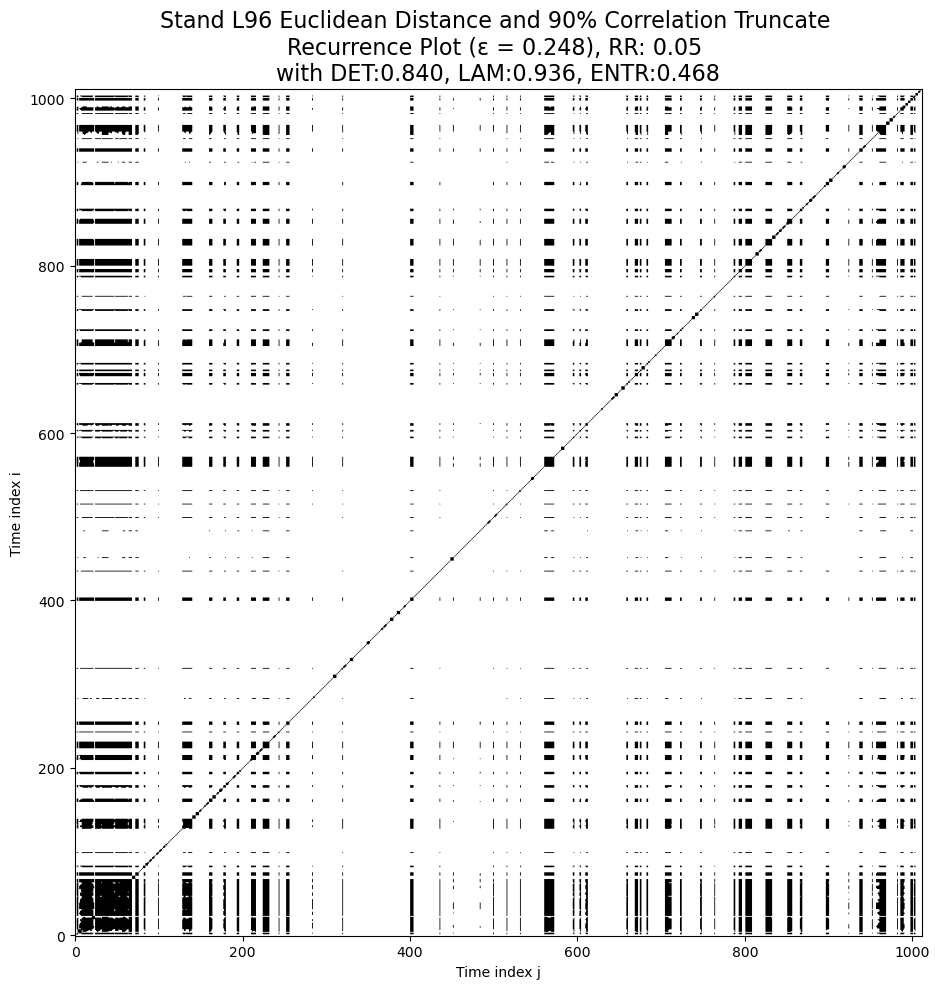

In [5]:
all_vectors = all_vectors_new
p=5
metrics = rqa.RecurrencePlot(all_vectors, percent=p, metric ='euclidean', plot = True, globalEpsilon=True, Title = 'Stand L96 Euclidean Distance and 90% Correlation Truncate',lines = False)

In [6]:
'''
from tqdm import tqdm
import time

total_time = X.shape[1]
window_size= .1 * total_time
one_side = window_size//2
times, det_ts, lam_ts, entr_ts = [], [], [], []
sub_dmd = DMD(svd_rank=0.75)
l=5
mrdmd = MrDMD(sub_dmd, max_level=l, max_cycles=1)
for t in tqdm(range(int(one_side), int(total_time - one_side))):
    time.sleep(0.1)
    block_X = X[:, int(t - one_side) : int(t + one_side) ]
    mrdmd.fit(block_X)
    last_dynamics = mrdmd.partial_dynamics(level=l)
    # last_dynamics = StandardScaler().fit_transform(last_dynamics.real)
    df_dynamics = tr.correlation_truncate(last_dynamics.T, threshold =0.80)
    all_vectors_new = df_dynamics.to_numpy()
    metrics,_ = rqa.RecurrencePlot(all_vectors_new, percent=p, globalEpsilon=True, plot=False)
    det_ts.append(metrics['DET'])
    lam_ts.append(metrics['LAM'])
    entr_ts.append(metrics['ENTR'])  
    times.append(t)
times = np.array(times)
DETS = det_ts
LAMS= lam_ts
ENTRS = entr_ts
np.save('final_times.npy', times)
np.save('final_ENTRS.npy', ENTRS)
np.save('final_LAMS.npy', LAMS)
np.save('final_DETS.npy', DETS)
print(times)
'''
total_time = X.shape[1]
window_size= .1 * total_time
one_side = window_size//2

times = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_times.npy')

DETS = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_DETS.npy')
LAMS = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_LAMS.npy')
ENTRS = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_ENTRS.npy')

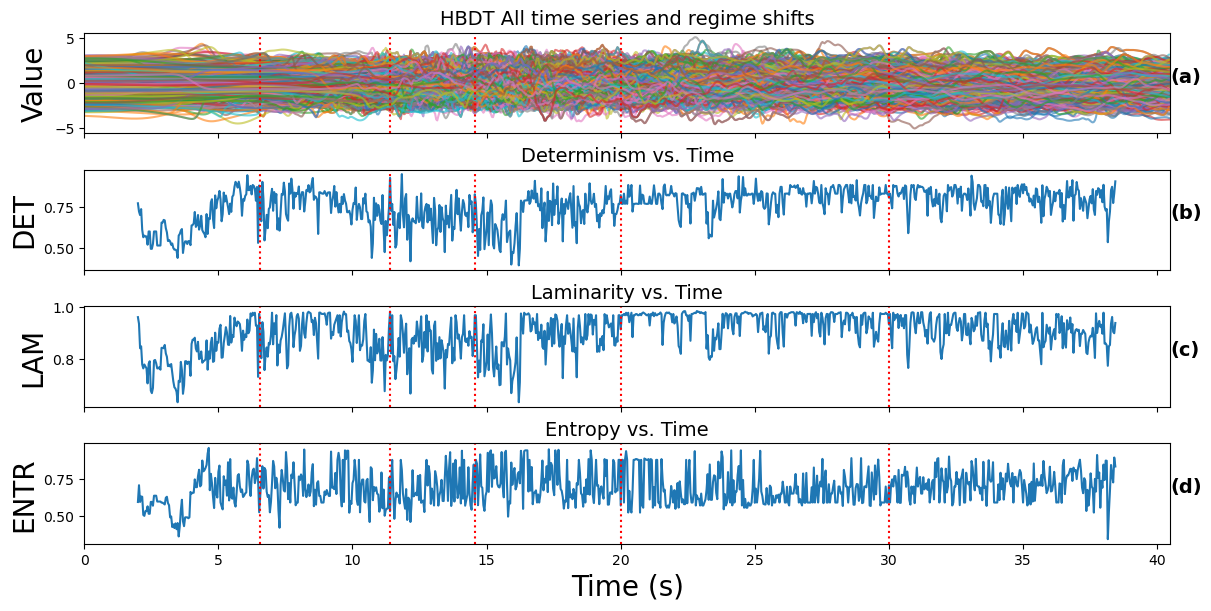

In [7]:
x=X
real_times = times * dt
total_time = X.shape[1] * dt
time_axis = np.arange(X.shape[1]) * dt

regime_times = [6.56, 11.4, 14.56, 20.0, 30.0]
regime_kwargs = dict(color='red', linestyle='dotted')

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)

labels = ['(a)', '(b)', '(c)', '(d)']

for row in X:
    axes[0].plot(time_axis, row, alpha=0.6)
axes[0].set_ylabel('Value', fontsize=20)
axes[0].set_title('HBDT All time series and regime shifts', fontsize=14)

for t in regime_times:
    axes[0].axvline(t, **regime_kwargs)
axes[0].text(1, 0.51, labels[0], transform=axes[0].transAxes,
             fontsize=14, fontweight='bold')

axes[1].plot(real_times, DETS)
axes[1].set_ylabel('DET', fontsize=20)
axes[1].set_title('Determinism vs. Time', fontsize=14)
for t in regime_times:
    axes[1].axvline(t, **regime_kwargs)
axes[1].text(1, 0.51, labels[1], transform=axes[1].transAxes,
             fontsize=14, fontweight='bold')

axes[2].plot(real_times, LAMS)
axes[2].set_ylabel('LAM', fontsize=20)
axes[2].set_title('Laminarity vs. Time', fontsize=14)
for t in regime_times:
    axes[2].axvline(t, **regime_kwargs)
axes[2].text(1, 0.51, labels[2], transform=axes[2].transAxes,
             fontsize=14, fontweight='bold')

axes[3].plot(real_times, ENTRS)
axes[3].set_ylabel('ENTR', fontsize=20)
axes[3].set_title('Entropy vs. Time', fontsize=14)
for t in regime_times:
    axes[3].axvline(t, **regime_kwargs)
axes[3].text(1,0.51, labels[3], transform=axes[3].transAxes,
             fontsize=14, fontweight='bold')

axes[3].set_xlabel('Time (s)', fontsize=20)
axes[3].set_xlim(0, total_time)

plt.show()
plt.show()

In [8]:
from scipy.signal import savgol_filter
DETS = savgol_filter(DETS, int(window_size//2), 2)
ENTRS = savgol_filter(ENTRS, int(window_size//2), 2)
LAMS = savgol_filter(LAMS, int(window_size//2), 2)
print(times)

[ 50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157
 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175
 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193
 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211
 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229
 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265
 266 267 268 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283
 284 285 286 287 288 289 290 291 292 293 294 295 29

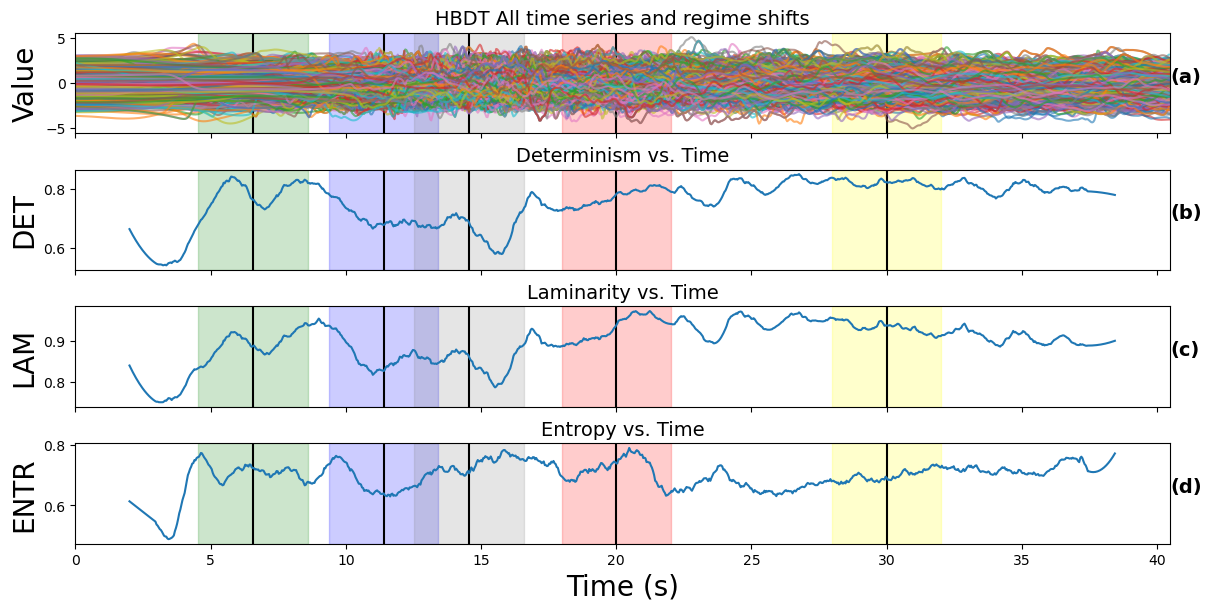

In [9]:
x=X
total_time = X.shape[1] * dt
real_times = times * dt
time_axis =  np.arange(X.shape[1])*dt

regime_times_real = [6.56, 11.4, 14.56, 20.0, 30.0]

window_real = window_size * (total_time / (x.shape[1]))



fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)

labels = ['(a)', '(b)', '(c)', '(d)']
regime_kwargs = dict(color='black', linestyle='solid')
i = 0 
colors = ['green', 'blue', 'gray', 'red', 'yellow']
for ax in axes:
    for t_real in regime_times_real:
        ax.axvline(t_real, **regime_kwargs)
        ax.axvspan(t_real - window_real/2, t_real + window_real/2, color=colors[i], alpha=0.2)
        i = (i+1)%5

        
for row in X:
    axes[0].plot(time_axis, row, alpha=0.6)
axes[0].set_ylabel('Value', fontsize=20)
axes[0].set_title('HBDT All time series and regime shifts', fontsize=14)

axes[1].plot(real_times, DETS)
axes[1].set_ylabel('DET', fontsize=20)
axes[1].set_title('Determinism vs. Time', fontsize=14)

axes[2].plot(real_times, LAMS)
axes[2].set_ylabel('LAM', fontsize=20)
axes[2].set_title('Laminarity vs. Time', fontsize=14)

axes[3].plot(real_times, ENTRS)
axes[3].set_ylabel('ENTR', fontsize=20)
axes[3].set_title('Entropy vs. Time', fontsize=14)
axes[3].set_xlabel('Time (s)', fontsize=20)
axes[3].set_xlim(0, total_time)

for ax, label in zip(axes, labels):
    ax.text(1, 0.51, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold')

plt.show()

In [10]:
print(window_real/2)
print(11.4-(window_real/2))
print(11.4+(window_real/2))
print(14.56-(window_real/2))
print(14.56+(window_real/2))

2.024
9.376000000000001
13.424
12.536000000000001
16.584


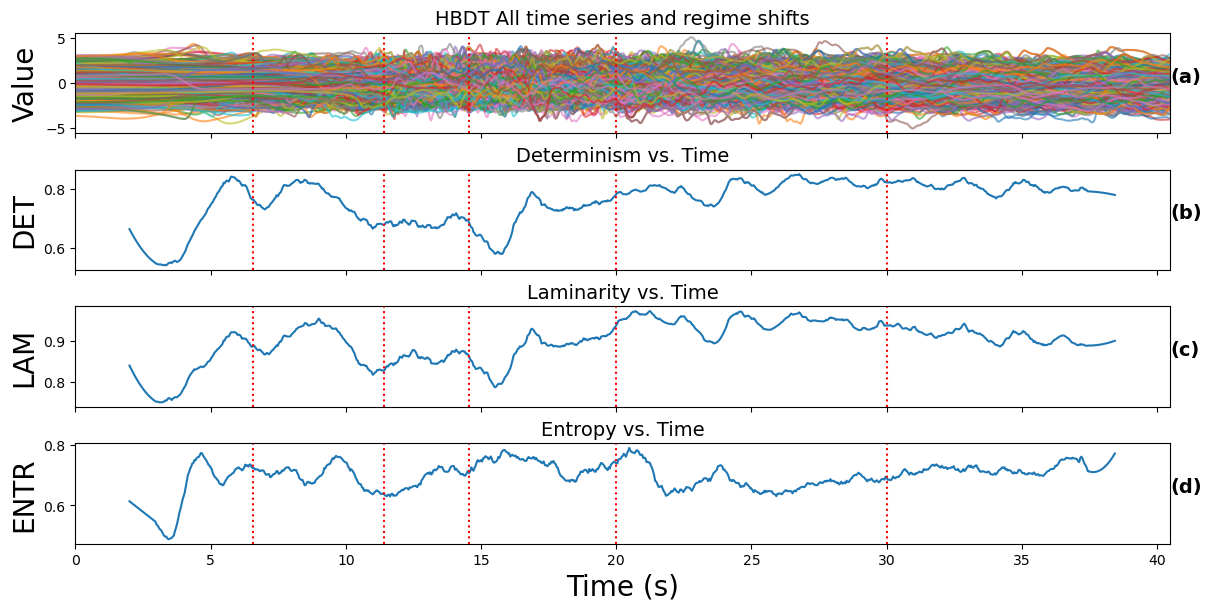

In [11]:
real_times = times * dt
total_time = X.shape[1] * dt
time_axis = np.arange(X.shape[1]) * dt

regime_times = [6.56, 11.4, 14.56, 20.0, 30.0]
regime_kwargs = dict(color='red', linestyle='dotted')

i = 0 
colors = ['green', 'blue', 'gray', 'red', 'yellow']
for ax in axes:
    for t_real in regime_times_real:
        ax.axvline(t_real, **regime_kwargs)
        ax.axvspan(t_real - window_real/2, t_real + window_real/2, color=colors[i], alpha=0.2)
        i = (i+1)%5
        
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)

labels = ['(a)', '(b)', '(c)', '(d)']

for row in X:
    axes[0].plot(time_axis, row, alpha=0.6)
axes[0].set_ylabel('Value', fontsize=20)
axes[0].set_title('HBDT All time series and regime shifts', fontsize=14)
for t in regime_times:
    axes[0].axvline(t, **regime_kwargs)
axes[0].text(1, 0.51, labels[0], transform=axes[0].transAxes,
             fontsize=14, fontweight='bold')

axes[1].plot(real_times, DETS)
axes[1].set_ylabel('DET', fontsize=20)
axes[1].set_title('Determinism vs. Time', fontsize=14)
for t in regime_times:
    axes[1].axvline(t, **regime_kwargs)
axes[1].text(1, 0.51, labels[1], transform=axes[1].transAxes,
             fontsize=14, fontweight='bold')

axes[2].plot(real_times, LAMS)
axes[2].set_ylabel('LAM', fontsize=20)
axes[2].set_title('Laminarity vs. Time', fontsize=14)
for t in regime_times:
    axes[2].axvline(t, **regime_kwargs)
axes[2].text(1, 0.51, labels[2], transform=axes[2].transAxes,
             fontsize=14, fontweight='bold')

axes[3].plot(real_times, ENTRS)
axes[3].set_ylabel('ENTR', fontsize=20)
axes[3].set_title('Entropy vs. Time', fontsize=14)
for t in regime_times:
    axes[3].axvline(t, **regime_kwargs)
axes[3].text(1,0.51, labels[3], transform=axes[3].transAxes,
             fontsize=14, fontweight='bold')

axes[3].set_xlabel('Time (s)', fontsize=20)
axes[3].set_xlim(0, total_time)

plt.show()

In [12]:
times = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_times.npy')

REAL_DETS = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_DETS.npy')
REAL_LAMS = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_LAMS.npy')
REAL_ENTRS = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_ENTRS.npy')


In [13]:
import random

def get_metrics(DETS,LAMS,ENTRS,n):
    sampled_dets = []
    sampled_lams = []
    sampled_entr = []
    sampled_ratio = []
    N = DETS.shape[0] - 1
    for i in range(0,n):
        random_number = random.randint(0, N)
        det = DETS[random_number]
        lam = LAMS[random_number]
        entr = ENTRS[random_number]
        '''
                block = x[int(random_number-window_size//2): int(random_number+window_size//2)]
        metrics,_ = rqa.RecurrencePlot(block, percent=p, metric ='euclidean', globalEpsilon=True)
        det = metrics['DET']
        lam = metrics['LAM']
        entr = metrics['ENTR']
        '''
        sampled_dets.append(det)
        sampled_lams.append(lam)
        sampled_entr.append(entr)
    return sampled_dets, sampled_lams, sampled_entr
sampled_dets, sampled_lams, sampled_entr = get_metrics(DETS,LAMS,ENTRS,10000)


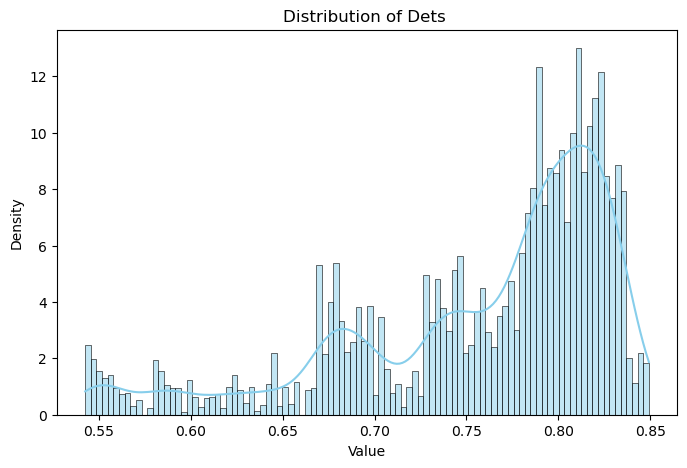

0.5871204419825216 0.8334760989365066


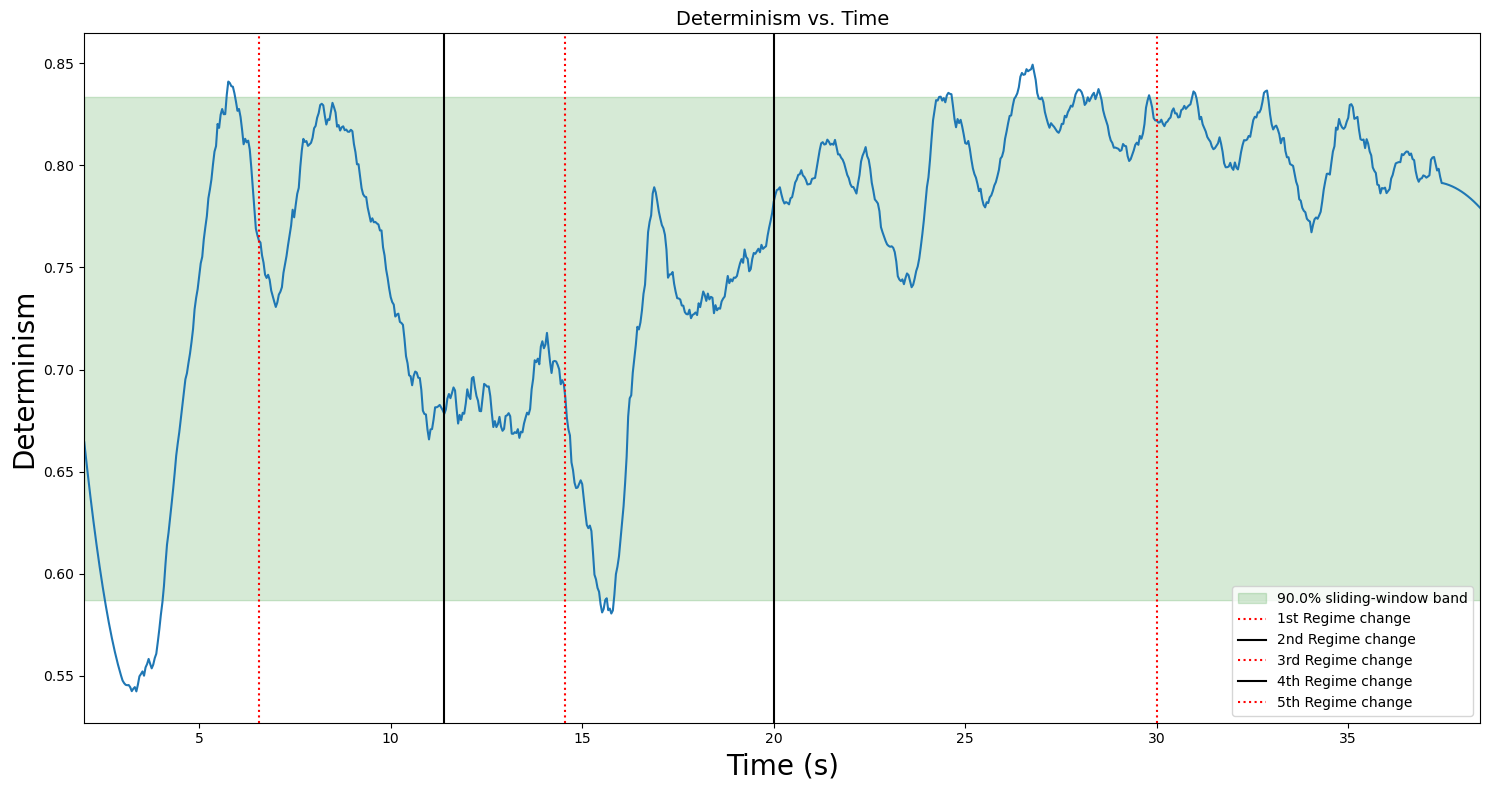

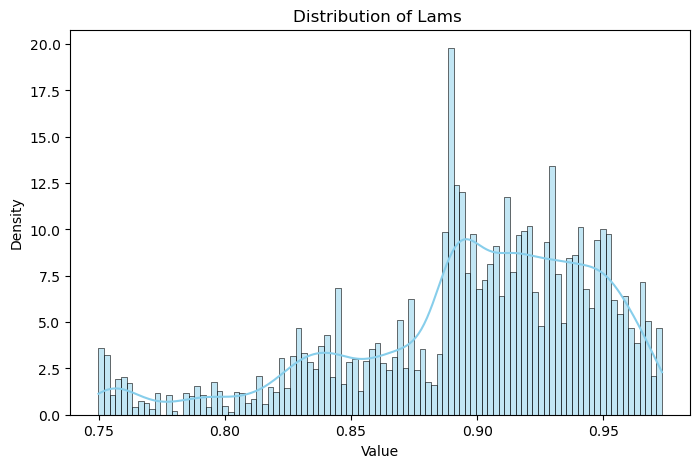

0.7920331765809336 0.9622930829964764


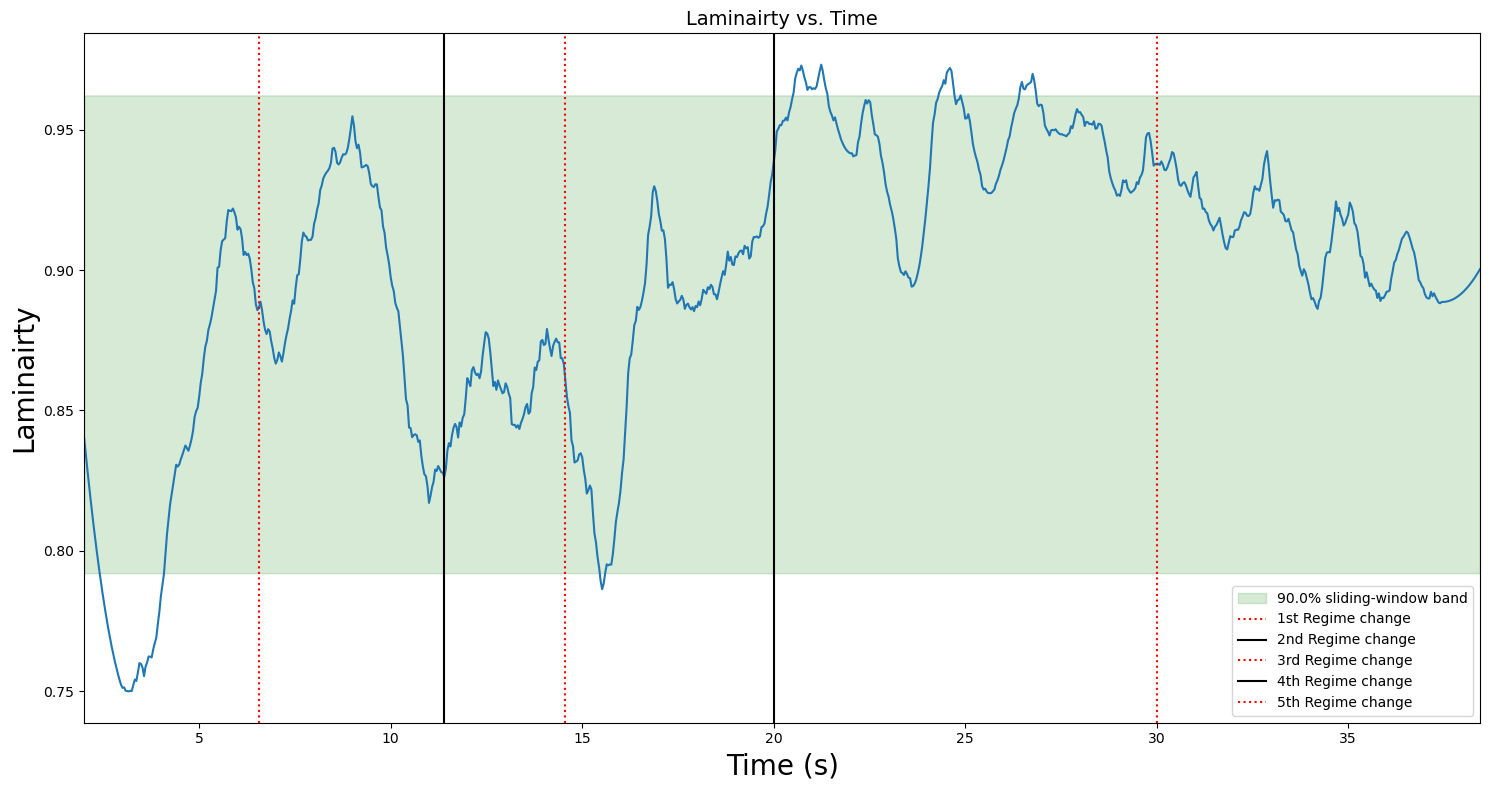

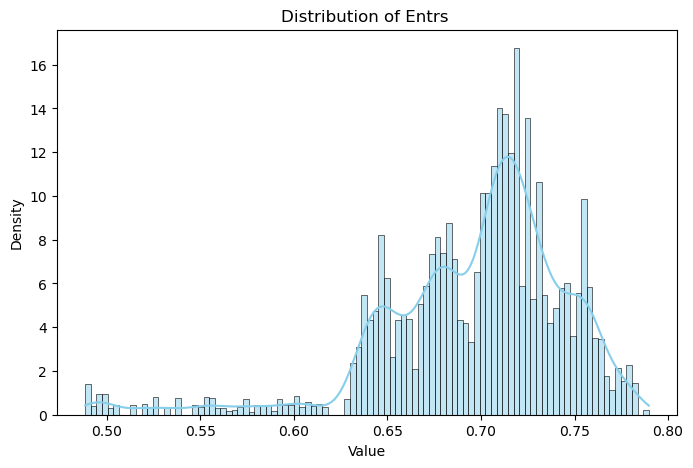

0.6077581532969756 0.7597469775239201


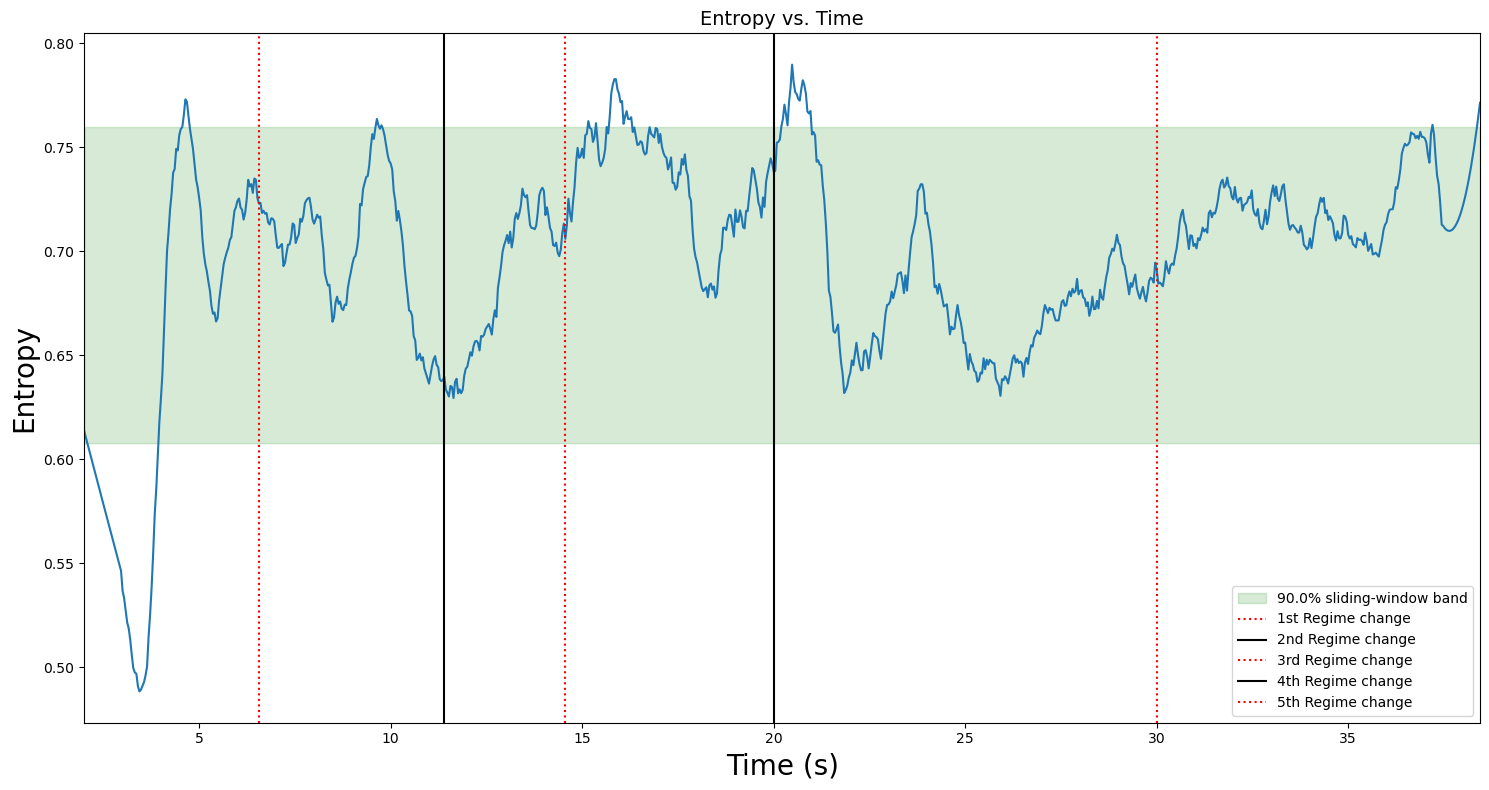

In [14]:
import seaborn as sns
def bootstrap_ci(sampled_metric,n,alpha=0.05,plot=False, metric_name=''):
    if plot:
        plt.figure(figsize=(8, 5))
        sns.histplot(sampled_metric, bins=len(sampled_metric)//100, kde=True, stat="density", color="skyblue", edgecolor="black")
        plt.title(f"Distribution of {metric_name} ")
        plt.xlabel("Value")
        plt.ylabel("Density")
        plt.show()
    lo, hi = np.percentile(sampled_metric, [100*alpha/2, 100*(1-alpha/2)])
    print(lo,hi)
    return lo,hi
def plotting(metric, metric_name, lo,hi, percent, real_times = real_times):
    plt.figure(figsize=(15,8))
    plt.plot(real_times, metric)
    plt.ylabel(f'{metric_name}', fontsize=20)
    plt.title(f'{metric_name} vs. Time', fontsize=14)
    plt.xlabel('Time (s)', fontsize=20)
    plt.xlim(real_times[0], real_times[-1])
    plt.fill_between(real_times, lo, hi, alpha=0.16, label=f'{100-percent}% sliding-window band', zorder=1, color='green')
    plt.axvline(6.56, color='red', linestyle='dotted', label='1st Regime change')
    plt.axvline(11.4, color='Black', linestyle='solid', label='2nd Regime change')
    plt.axvline(14.56, color='red', linestyle='dotted', label='3rd Regime change')
    plt.axvline(20, color='Black', linestyle='solid', label='4th Regime change')
    plt.axvline(30, color='red', linestyle='dotted', label='5th Regime change')
    plt.tight_layout()
    plt.legend()
    plt.show()
    
alpha=0.1
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
plotting(DETS, 'Determinism', lo,hi, alpha*100)
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
plotting(LAMS, 'Laminairty', lo,hi, alpha*100)
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')
plotting(ENTRS, 'Entropy', lo,hi, alpha*100)


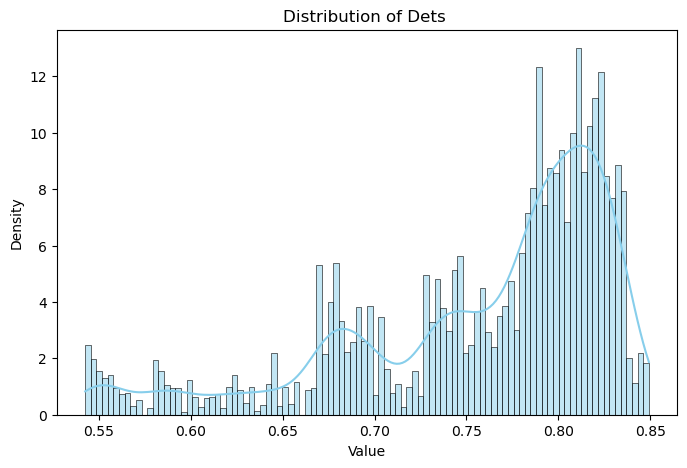

0.5871204419825216 0.8334760989365066
635 and 0.6962719298245614


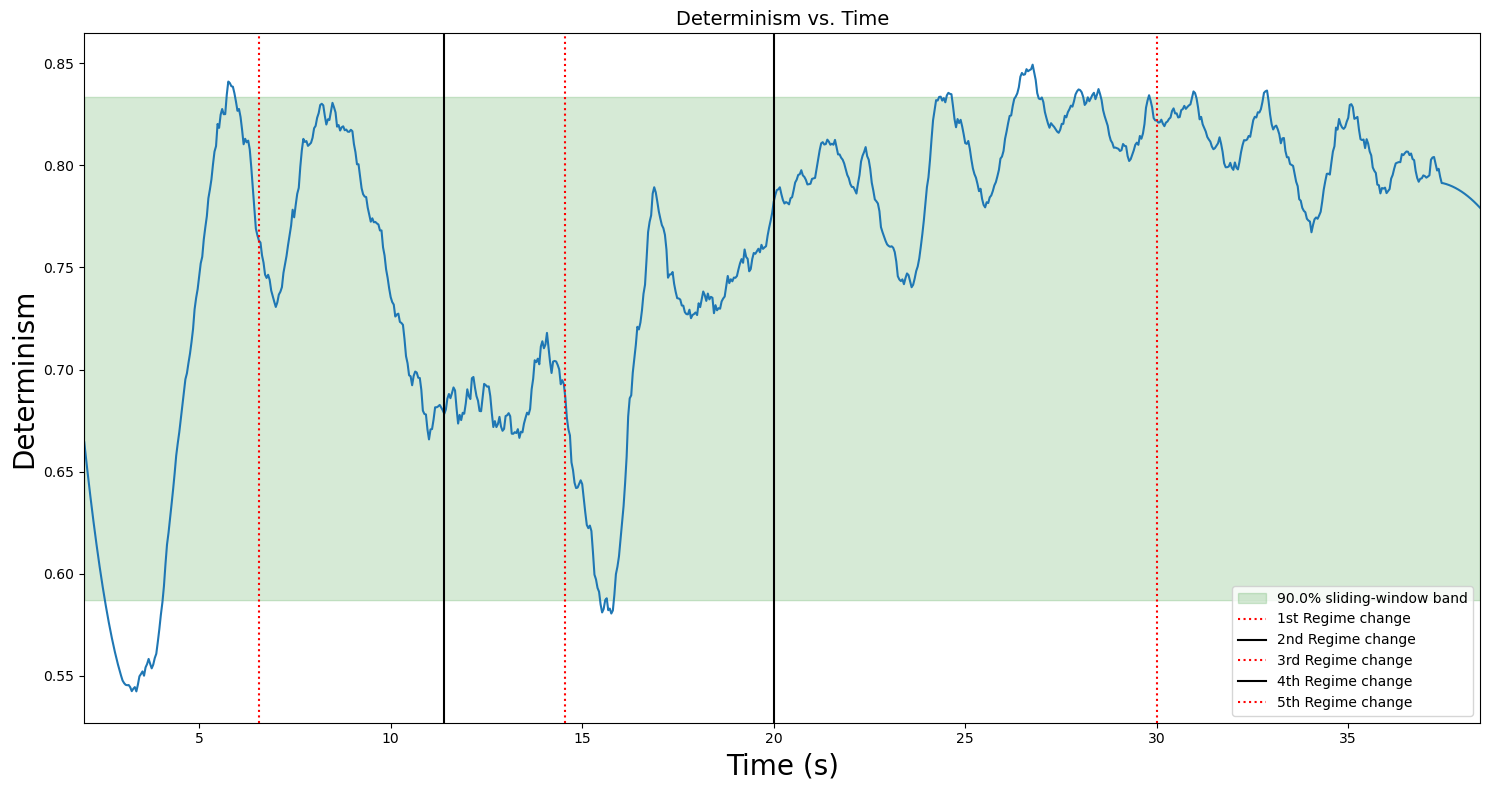

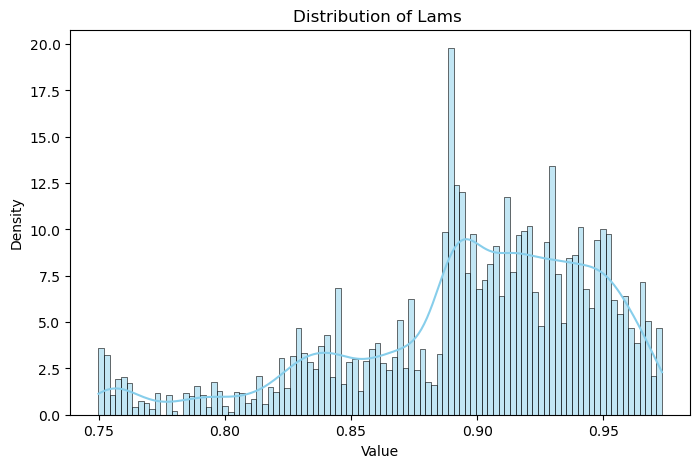

0.7920331765809336 0.9622930829964764


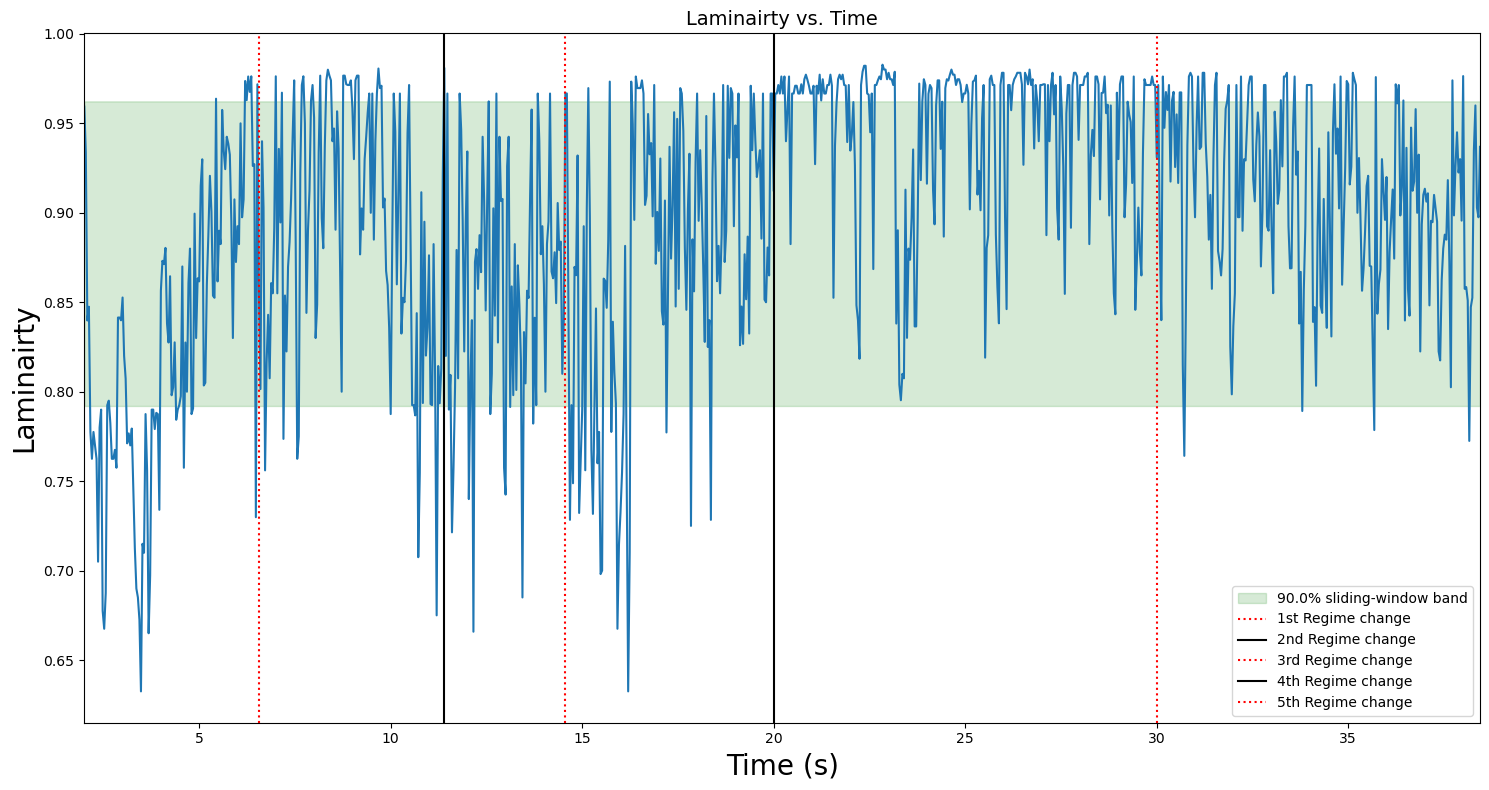

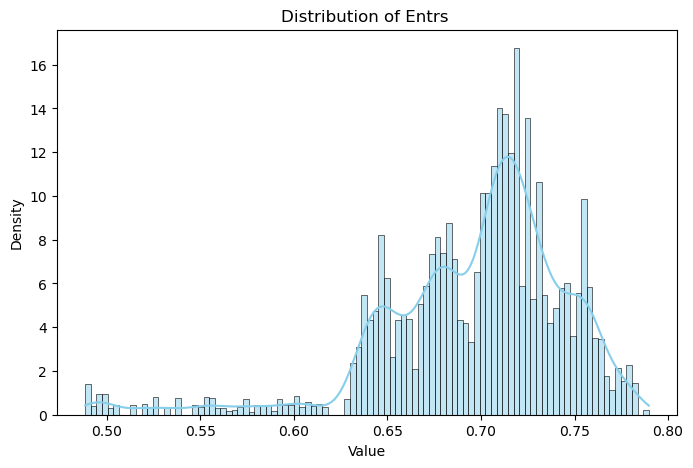

0.6077581532969756 0.7597469775239201


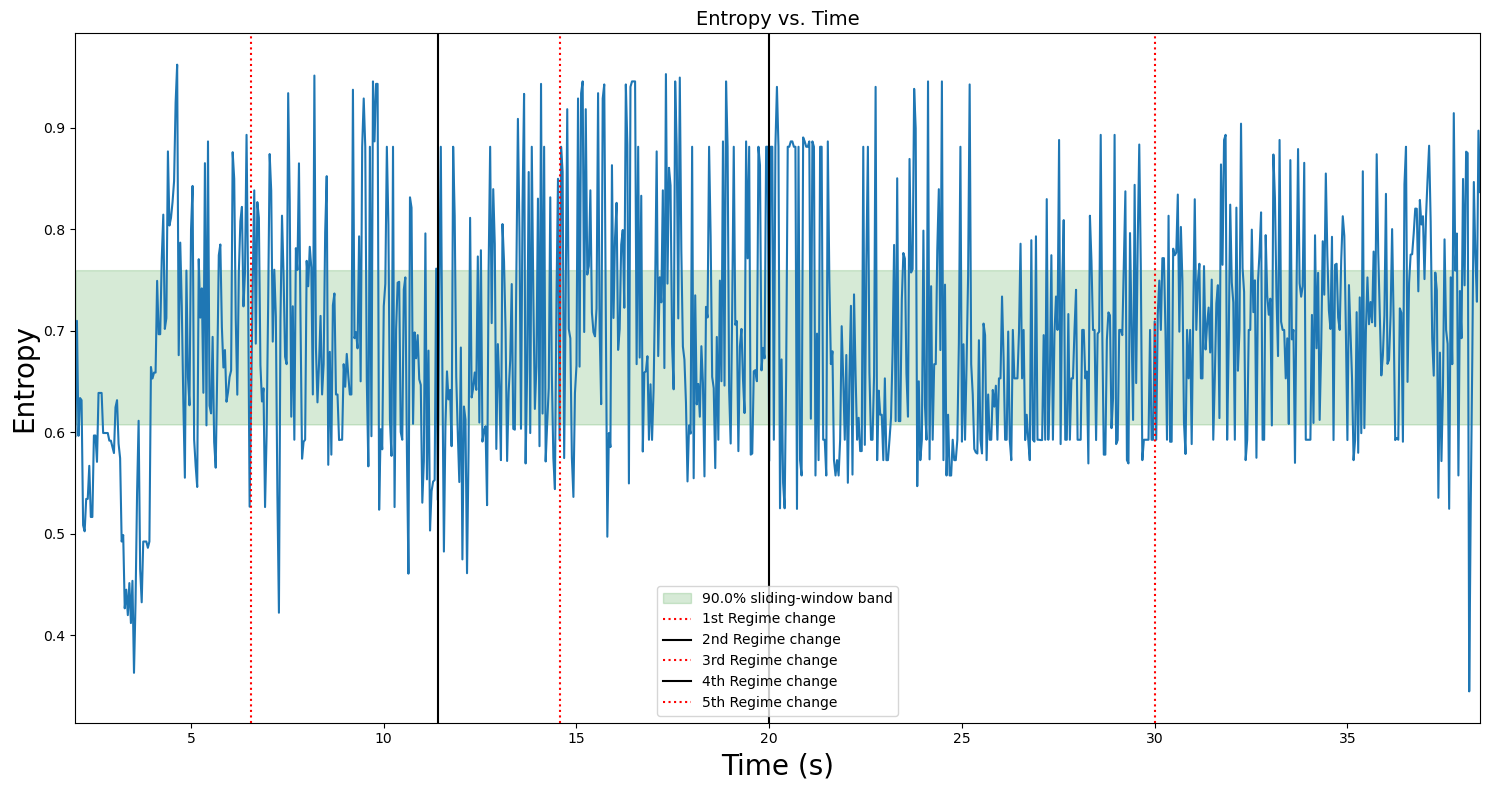

In [15]:
#Trapping time 
#Ratio, 
#avg, dia, avg line negth
alpha=0.1
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
filtered_values = [value for value in REAL_DETS if lo <= value <= hi]
count = len(filtered_values)
print(f"{count} and {count/len(REAL_DETS)}")
    
    
    
plotting(DETS, 'Determinism', lo,hi, alpha*100)
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
plotting(REAL_LAMS, 'Laminairty', lo,hi, alpha*100)
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')
plotting(REAL_ENTRS, 'Entropy', lo,hi, alpha*100)

In [16]:
# after smoothing take deriv, rate of change
# Fix test, regime changes merge(4-5)
# fewer, and test changes


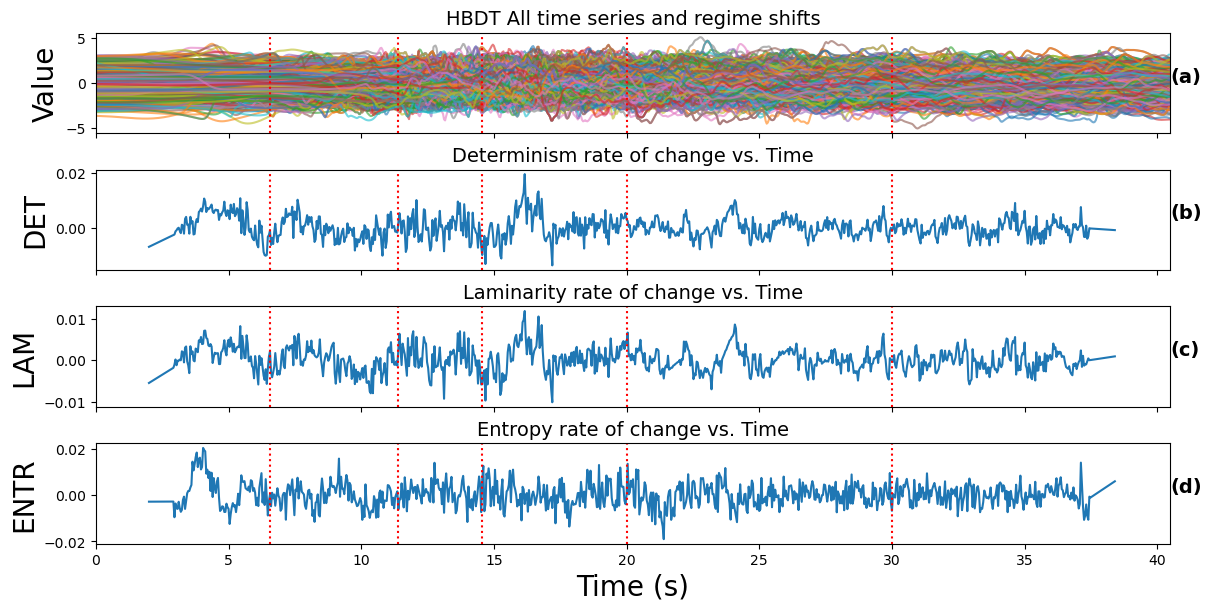

In [17]:
# Derivative time series
DET_Deriv= np.diff(DETS)
LAM_Deriv= np.diff(LAMS)
ENTR_Deriv= np.diff(ENTRS)


real_times = times * dt
real_times = real_times[0:911]
total_time = X.shape[1] * dt
time_axis = np.arange(X.shape[1]) * dt

regime_times = [6.56, 11.4, 14.56, 20.0, 30.0]
regime_kwargs = dict(color='red', linestyle='dotted')

i = 0 
colors = ['green', 'blue', 'gray', 'red', 'yellow']
for ax in axes:
    for t_real in regime_times_real:
        ax.axvline(t_real, **regime_kwargs)
        ax.axvspan(t_real - window_real/2, t_real + window_real/2, color=colors[i], alpha=0.2)
        i = (i+1)%5
        
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)

labels = ['(a)', '(b)', '(c)', '(d)']

for row in X:
    axes[0].plot(time_axis, row, alpha=0.6)
axes[0].set_ylabel('Value', fontsize=20)
axes[0].set_title('HBDT All time series and regime shifts', fontsize=14)
for t in regime_times:
    axes[0].axvline(t, **regime_kwargs)
axes[0].text(1, 0.51, labels[0], transform=axes[0].transAxes,
             fontsize=14, fontweight='bold')

axes[1].plot(real_times, DET_Deriv)
axes[1].set_ylabel('DET', fontsize=20)
axes[1].set_title('Determinism rate of change vs. Time', fontsize=14)
for t in regime_times:
    axes[1].axvline(t, **regime_kwargs)
axes[1].text(1, 0.51, labels[1], transform=axes[1].transAxes,
             fontsize=14, fontweight='bold')

axes[2].plot(real_times, LAM_Deriv)
axes[2].set_ylabel('LAM', fontsize=20)
axes[2].set_title('Laminarity rate of change vs. Time', fontsize=14)
for t in regime_times:
    axes[2].axvline(t, **regime_kwargs)
axes[2].text(1, 0.51, labels[2], transform=axes[2].transAxes,
             fontsize=14, fontweight='bold')

axes[3].plot(real_times, ENTR_Deriv)
axes[3].set_ylabel('ENTR', fontsize=20)
axes[3].set_title('Entropy rate of change vs. Time', fontsize=14)
for t in regime_times:
    axes[3].axvline(t, **regime_kwargs)
axes[3].text(1,0.51, labels[3], transform=axes[3].transAxes,
             fontsize=14, fontweight='bold')

axes[3].set_xlabel('Time (s)', fontsize=20)
axes[3].set_xlim(0, total_time)

plt.show()


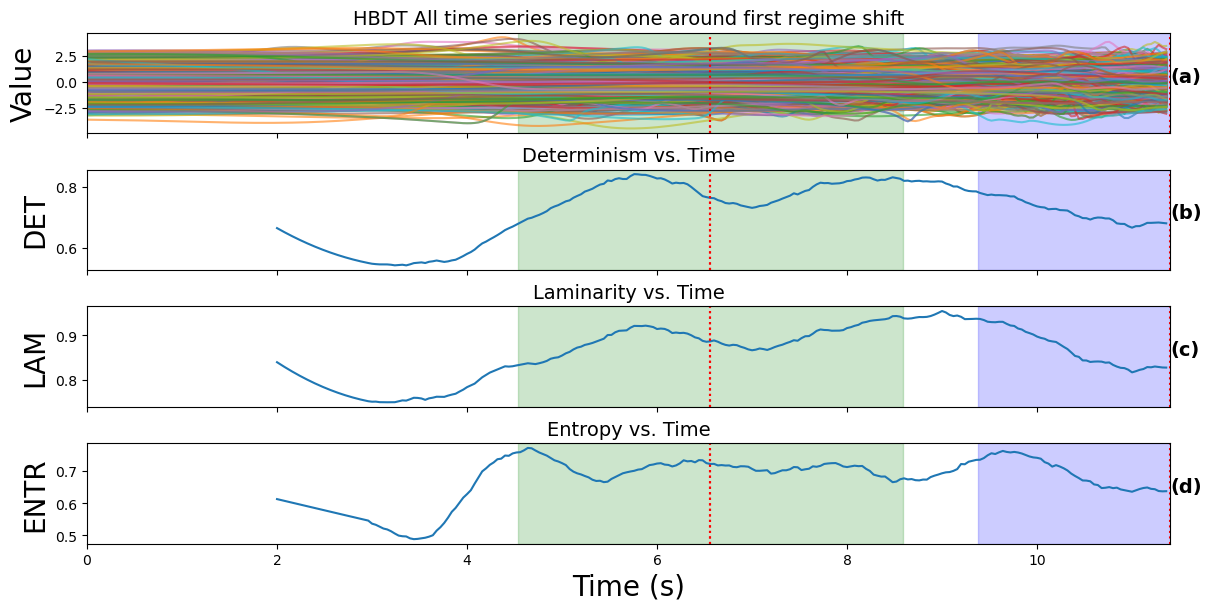

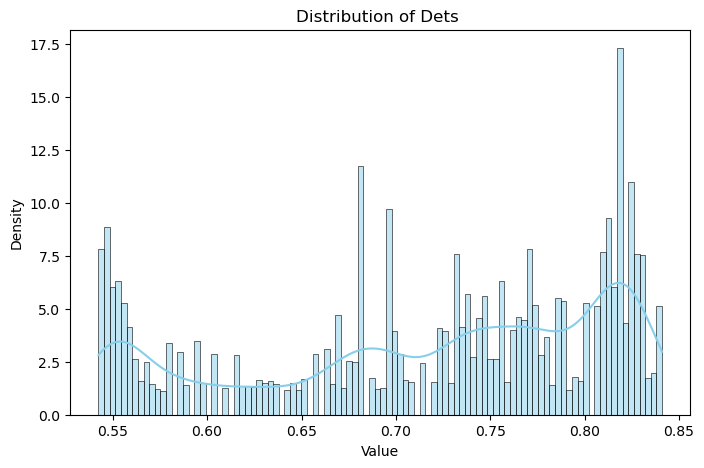

0.5498228575826013 0.8283889329824854


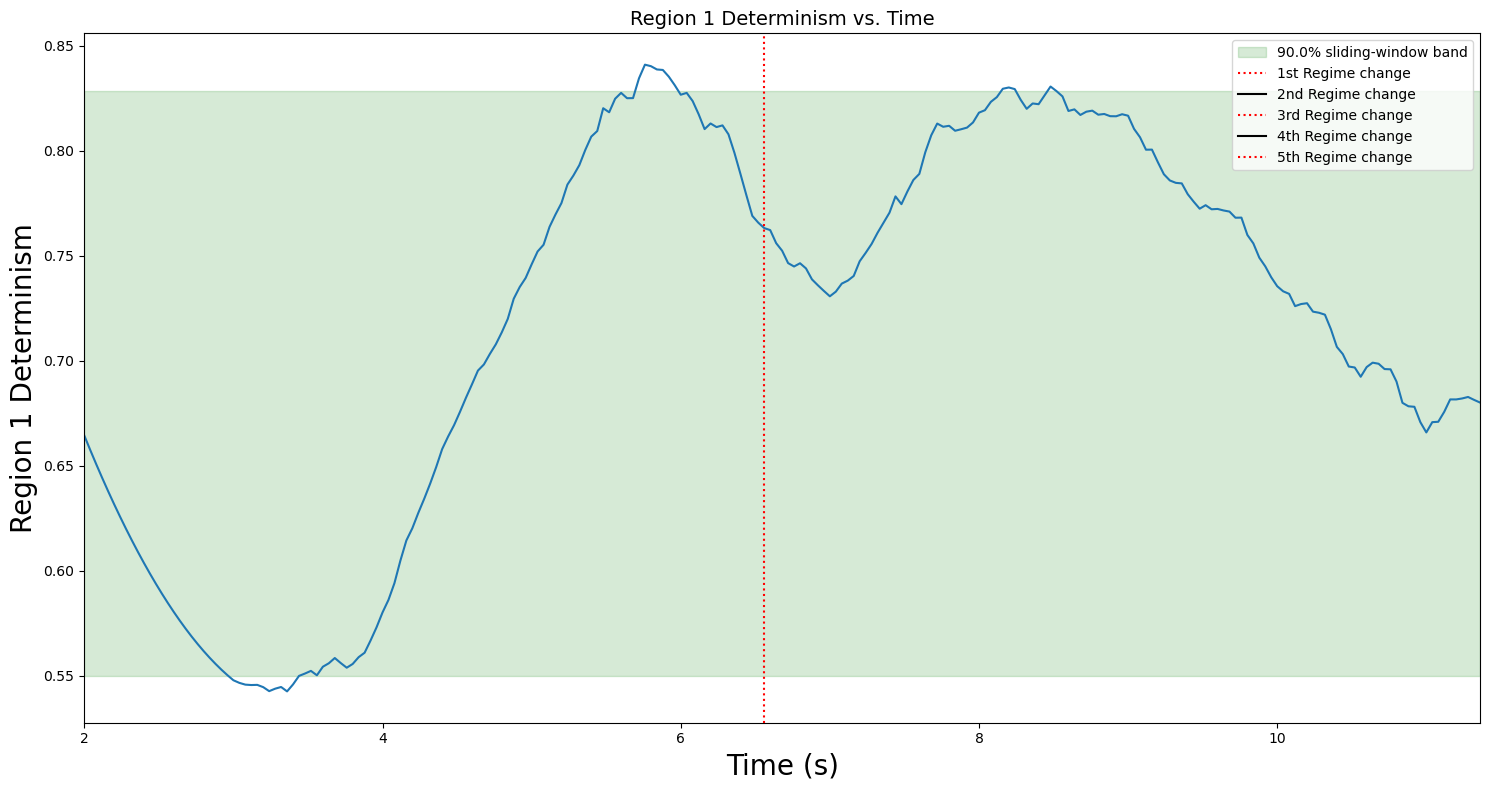

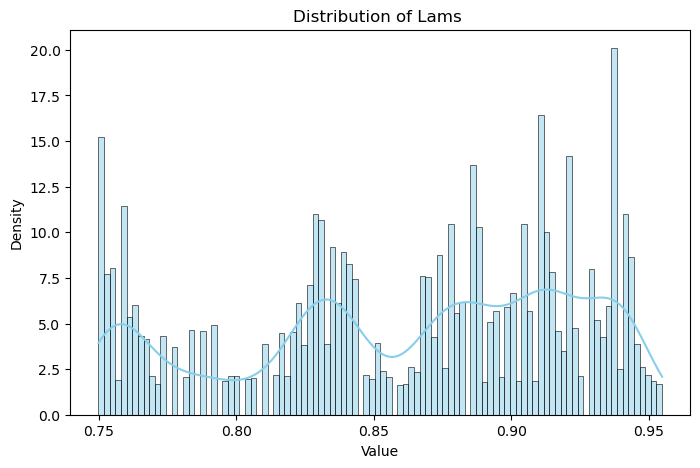

0.7540434261000835 0.9418954821488449


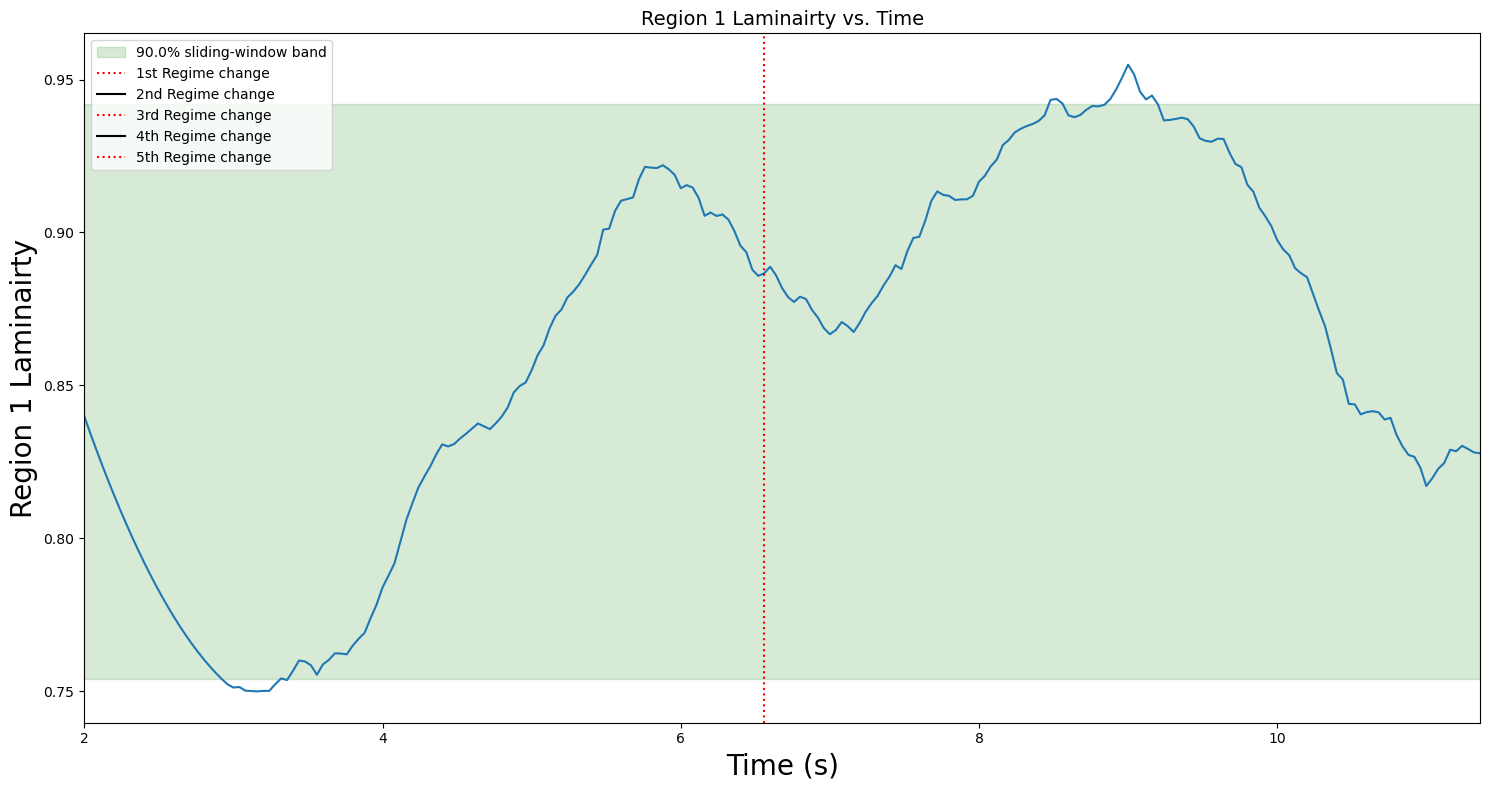

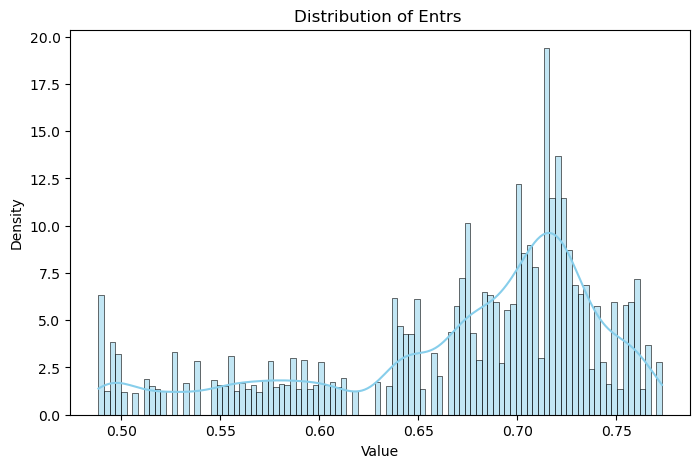

0.5131471520448291 0.7587877779102646


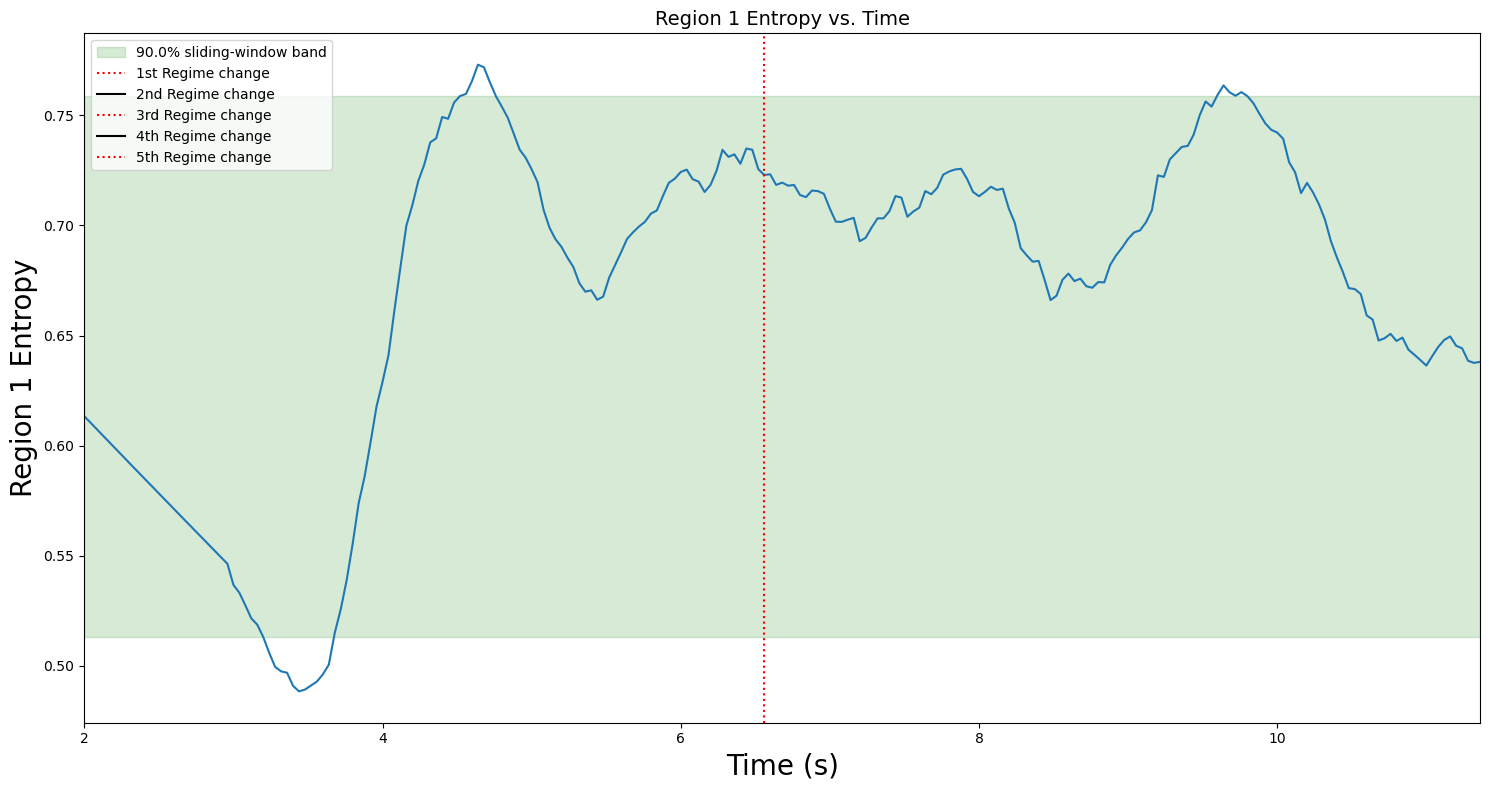

In [18]:
Change_one_DETS = DETS[:int((11.4/dt) - one_side)]
Change_one_LAMS = LAMS[:int((11.4/dt) - one_side)]
Change_one_ENTRS = ENTRS[:int((11.4/dt) - one_side)]
Change_one_times = times[:int((11.4/dt) - one_side)]
Change_one_real_times = dt * Change_one_times
change_one_X = X.T[0:285].T
real_times = Change_one_times * dt
total_time = change_one_X.shape[1] * dt
time_axis = np.arange(change_one_X.shape[1]) * dt

regime_times = [6.56]
regime_kwargs = dict(color='red', linestyle='dotted')
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
i = 0 
colors = ['green', 'blue', 'gray', 'red', 'yellow']
for ax in axes:
    for t_real in regime_times_real:
        ax.axvline(t_real, **regime_kwargs)
        ax.axvspan(t_real - window_real/2, t_real + window_real/2, color=colors[i], alpha=0.2)
        i = (i+1)%5
        

labels = ['(a)', '(b)', '(c)', '(d)']

for row in change_one_X:
    axes[0].plot(time_axis, row, alpha=0.6)
axes[0].set_ylabel('Value', fontsize=20)
axes[0].set_title('HBDT All time series region one around first regime shift', fontsize=14)
for t in regime_times:
    axes[0].axvline(t, **regime_kwargs)
axes[0].text(1, 0.51, labels[0], transform=axes[0].transAxes,
             fontsize=14, fontweight='bold')

axes[1].plot(Change_one_real_times, Change_one_DETS)
axes[1].set_ylabel('DET', fontsize=20)
axes[1].set_title('Determinism vs. Time', fontsize=14)
for t in regime_times:
    axes[1].axvline(t, **regime_kwargs)
axes[1].text(1, 0.51, labels[1], transform=axes[1].transAxes,
             fontsize=14, fontweight='bold')

axes[2].plot(Change_one_real_times, Change_one_LAMS)
axes[2].set_ylabel('LAM', fontsize=20)
axes[2].set_title('Laminarity vs. Time', fontsize=14)
for t in regime_times:
    axes[2].axvline(t, **regime_kwargs)
axes[2].text(1, 0.51, labels[2], transform=axes[2].transAxes,
             fontsize=14, fontweight='bold')

axes[3].plot(Change_one_real_times, Change_one_ENTRS)
axes[3].set_ylabel('ENTR', fontsize=20)
axes[3].set_title('Entropy vs. Time', fontsize=14)
for t in regime_times:
    axes[3].axvline(t, **regime_kwargs)
axes[3].text(1,0.51, labels[3], transform=axes[3].transAxes,
             fontsize=14, fontweight='bold')

axes[3].set_xlabel('Time (s)', fontsize=20)
axes[3].set_xlim(0, total_time)

plt.show()


sampled_dets, sampled_lams, sampled_entr = get_metrics(Change_one_DETS,Change_one_LAMS,Change_one_ENTRS,10000)

alpha=0.1
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
plotting(Change_one_DETS, 'Region 1 Determinism', lo,hi, alpha*100, Change_one_real_times)
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
plotting(Change_one_LAMS, 'Region 1 Laminairty', lo,hi, alpha*100,Change_one_real_times )
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')
plotting(Change_one_ENTRS, 'Region 1 Entropy', lo,hi, alpha*100, Change_one_real_times)




(2187, 200)
200
[0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08
 1.12 1.16 1.2  1.24 1.28 1.32 1.36 1.4  1.44 1.48 1.52 1.56 1.6  1.64
 1.68 1.72 1.76 1.8  1.84 1.88 1.92 1.96 2.   2.04 2.08 2.12 2.16 2.2
 2.24 2.28 2.32 2.36 2.4  2.44 2.48 2.52 2.56 2.6  2.64 2.68 2.72 2.76
 2.8  2.84 2.88 2.92 2.96 3.   3.04 3.08 3.12 3.16 3.2  3.24 3.28 3.32
 3.36 3.4  3.44 3.48 3.52 3.56 3.6  3.64 3.68 3.72 3.76 3.8  3.84 3.88
 3.92 3.96 4.   4.04 4.08 4.12 4.16 4.2  4.24 4.28 4.32 4.36 4.4  4.44
 4.48 4.52 4.56 4.6  4.64 4.68 4.72 4.76 4.8  4.84 4.88 4.92 4.96 5.
 5.04 5.08 5.12 5.16 5.2  5.24 5.28 5.32 5.36 5.4  5.44 5.48 5.52 5.56
 5.6  5.64 5.68 5.72 5.76 5.8  5.84 5.88 5.92 5.96 6.   6.04 6.08 6.12
 6.16 6.2  6.24 6.28 6.32 6.36 6.4  6.44 6.48 6.52 6.56 6.6  6.64 6.68
 6.72 6.76 6.8  6.84 6.88 6.92 6.96 7.   7.04 7.08 7.12 7.16 7.2  7.24
 7.28 7.32 7.36 7.4  7.44 7.48 7.52 7.56 7.6  7.64 7.68 7.72 7.7

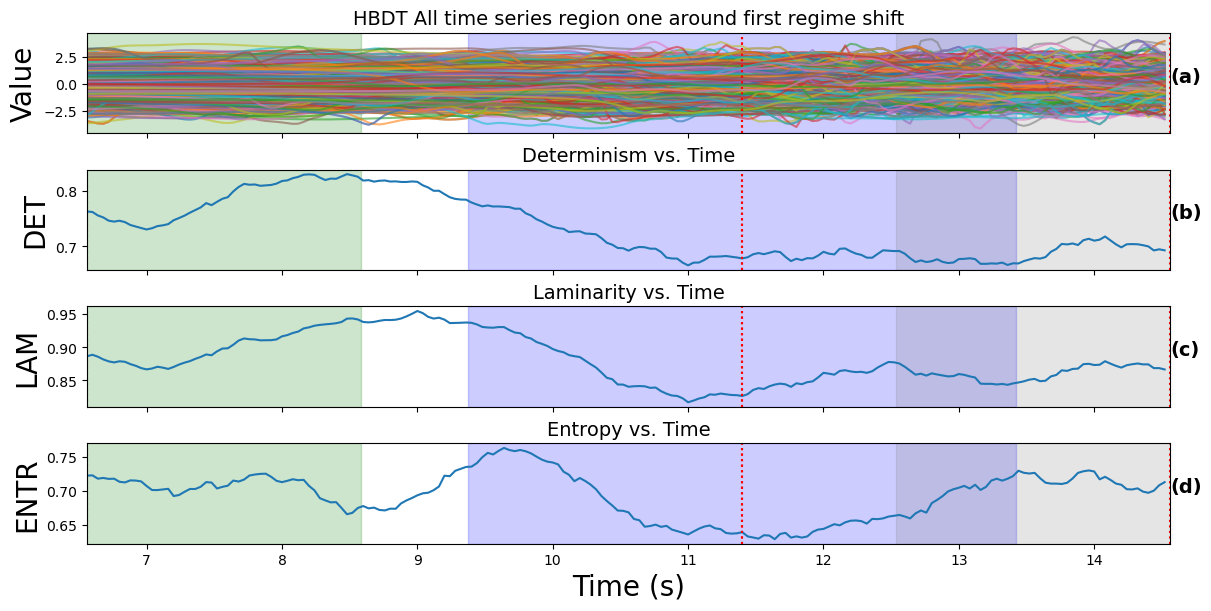

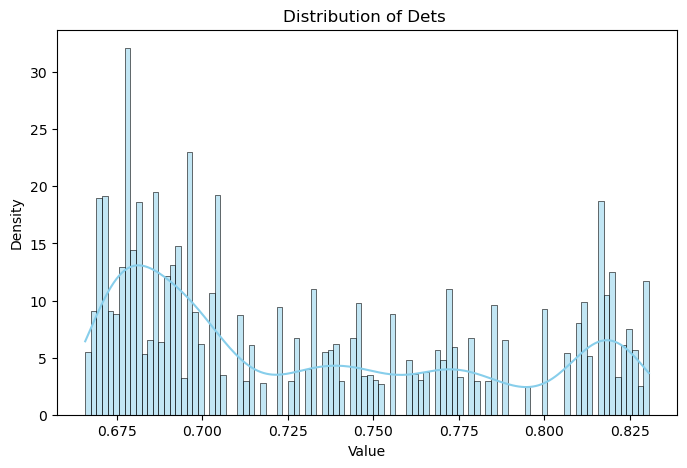

0.6706996012116182 0.8232972556641874


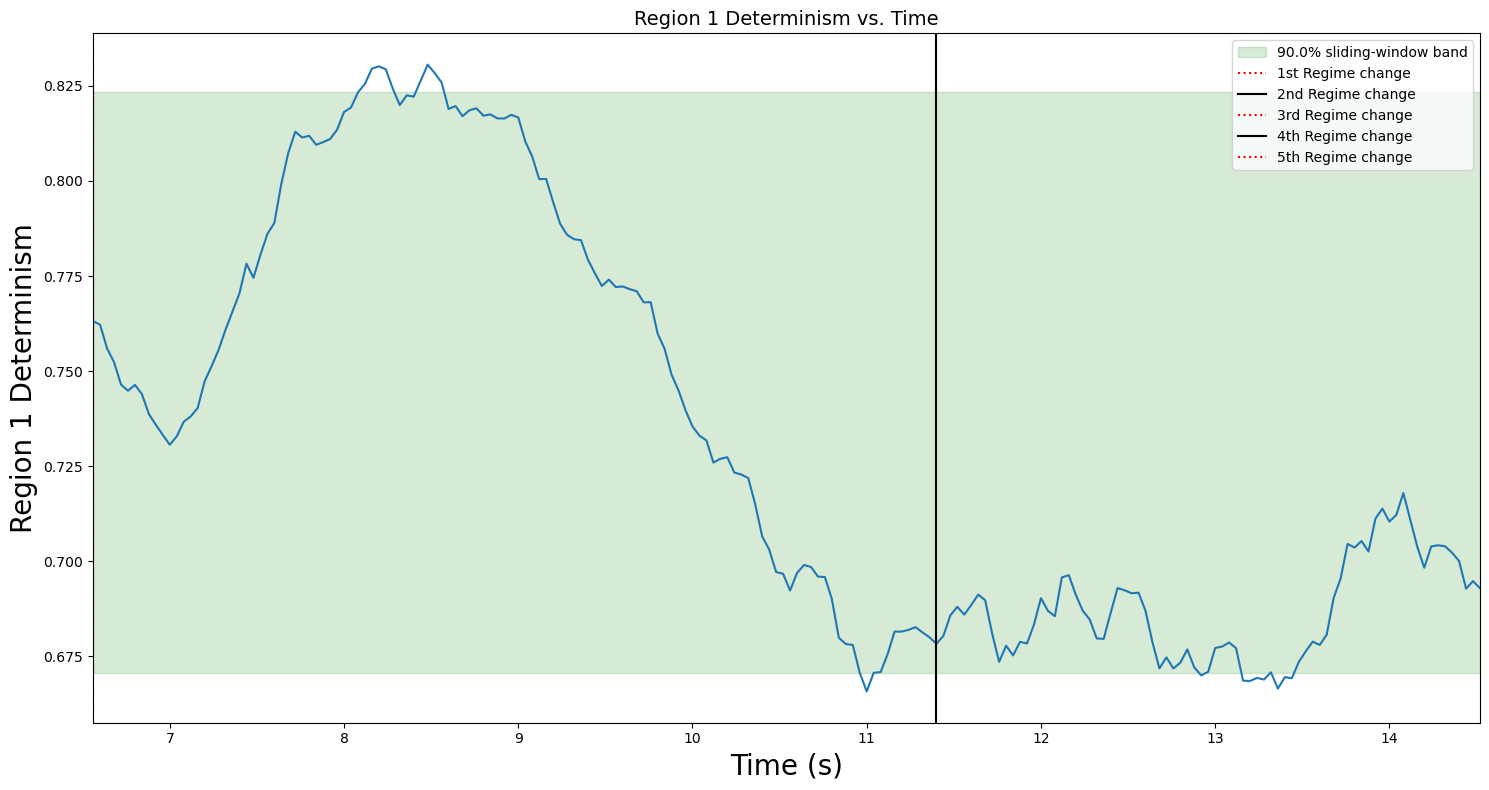

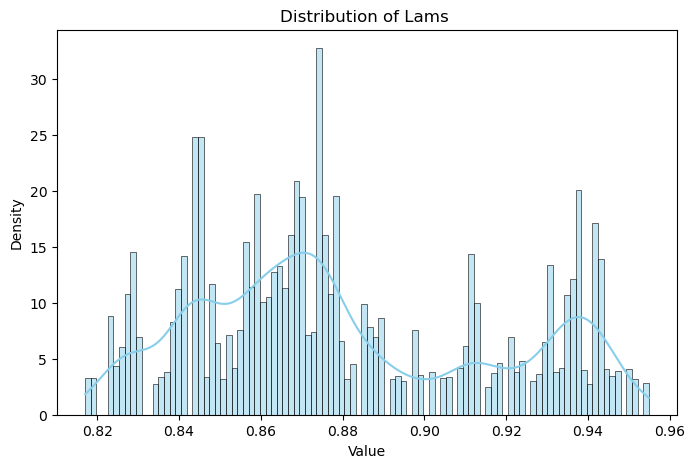

0.8280480796892856 0.9421603226514427


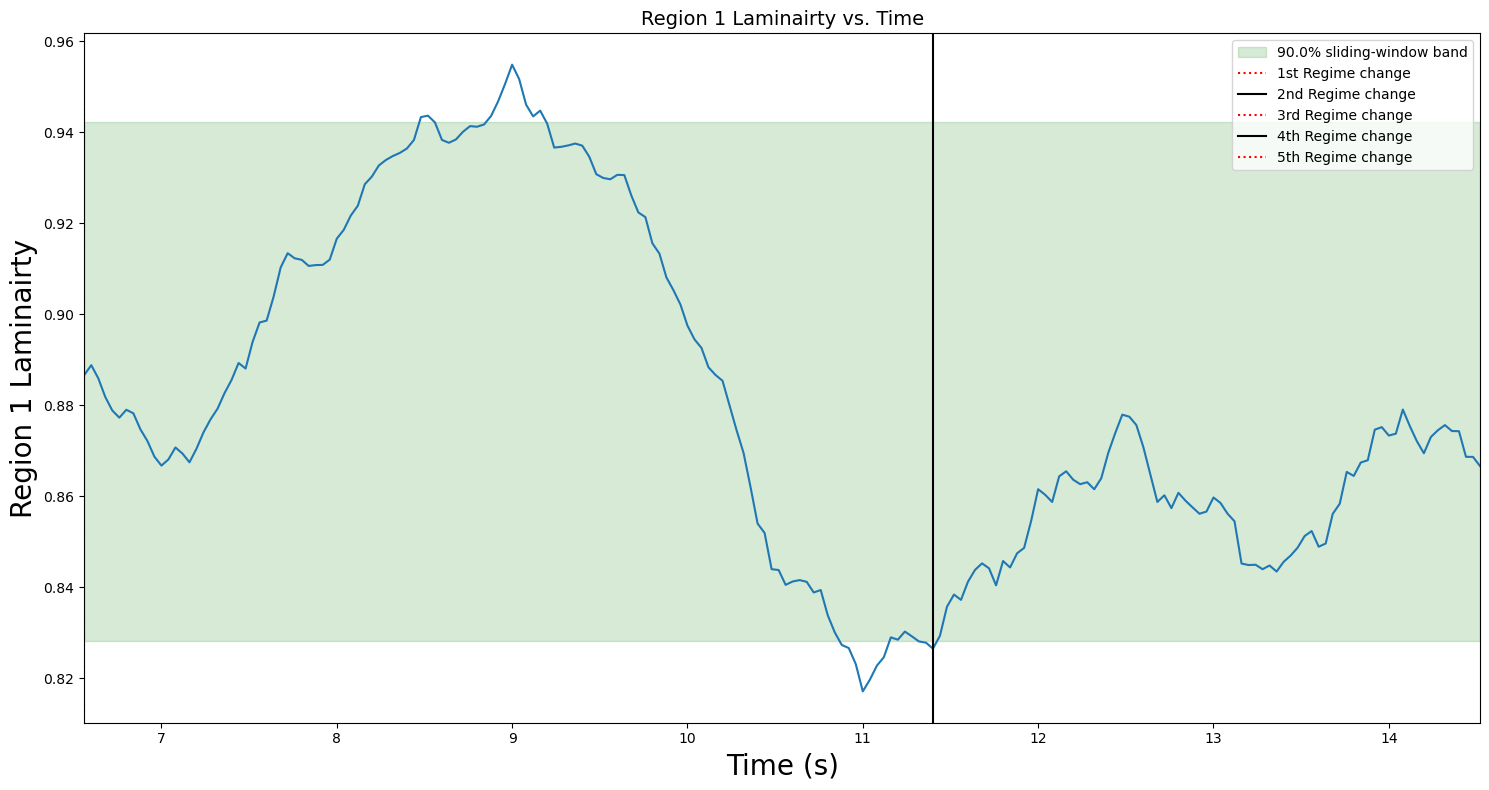

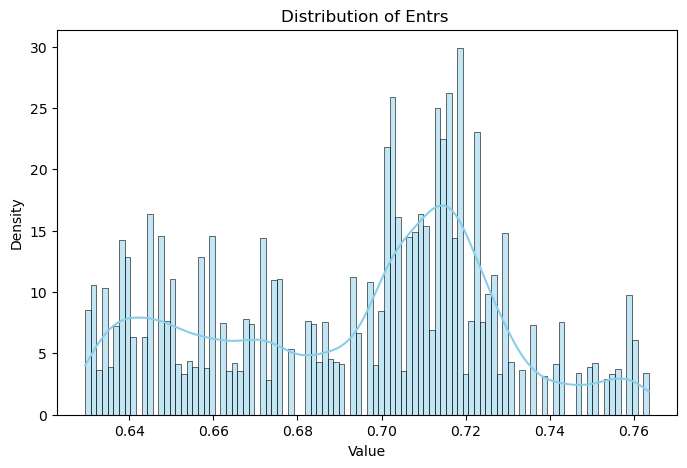

0.6363788283117987 0.7500021670507345


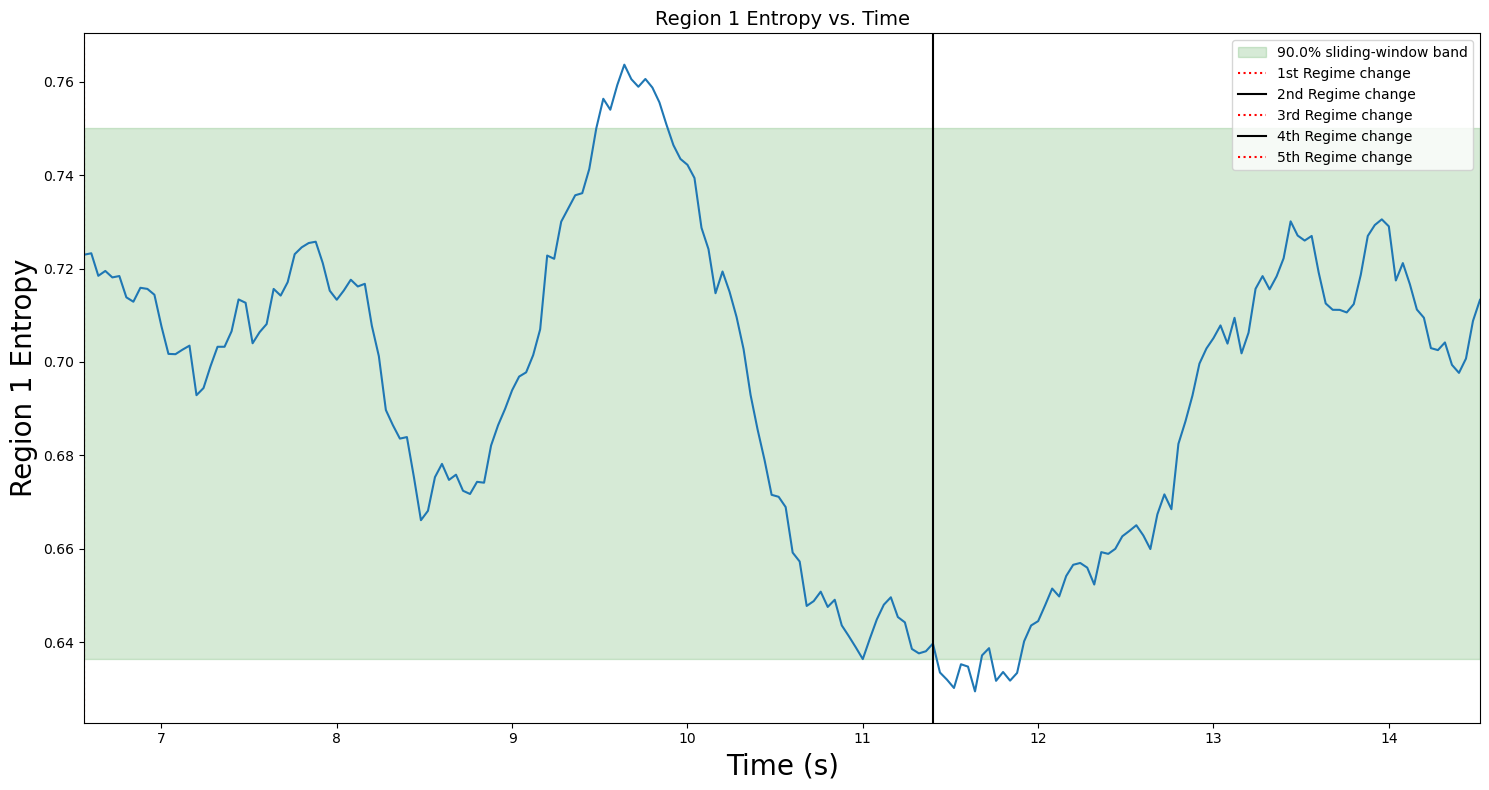

In [20]:
t1 = 6.56
t2 = 14.56
Change_one_DETS = DETS[int((t1/dt) - one_side): int((t2/dt) - one_side) ]
Change_one_LAMS = LAMS[int((t1/dt) - one_side): int((t2/dt) - one_side)]
Change_one_ENTRS = ENTRS[int((t1/dt) - one_side): int((t2/dt) - one_side)]
Change_one_times = times[int((t1/dt) - one_side): int((t2/dt) - one_side)]
Change_one_real_times = dt * Change_one_times
length = len(Change_one_DETS)
change_one_X = X.T[int((t1/dt)) : int((t2/dt))].T
real_times = Change_one_times * dt
total_time = change_one_X.shape[1] * dt
time_axis = np.arange(change_one_X.shape[1]) * dt
regime_times = [11.4]
regime_kwargs = dict(color='red', linestyle='dotted')
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
i = 0 
colors = ['green', 'blue', 'gray', 'red', 'yellow']
for ax in axes:
    for t_real in regime_times_real:
        ax.axvline(t_real, **regime_kwargs)
        ax.axvspan(t_real - window_real/2, t_real + window_real/2, color=colors[i], alpha=0.2)
        i = (i+1)%5
        

labels = ['(a)', '(b)', '(c)', '(d)']

for row in change_one_X:
    axes[0].plot(real_times, row, alpha=0.6)
axes[0].set_ylabel('Value', fontsize=20)
axes[0].set_title('HBDT All time series region one around first regime shift', fontsize=14)
for t in regime_times:
    axes[0].axvline(t, **regime_kwargs)
axes[0].text(1, 0.51, labels[0], transform=axes[0].transAxes,
             fontsize=14, fontweight='bold')

axes[1].plot(Change_one_real_times, Change_one_DETS)
axes[1].set_ylabel('DET', fontsize=20)
axes[1].set_title('Determinism vs. Time', fontsize=14)
for t in regime_times:
    axes[1].axvline(t, **regime_kwargs)
axes[1].text(1, 0.51, labels[1], transform=axes[1].transAxes,
             fontsize=14, fontweight='bold')

axes[2].plot(Change_one_real_times, Change_one_LAMS)
axes[2].set_ylabel('LAM', fontsize=20)
axes[2].set_title('Laminarity vs. Time', fontsize=14)
for t in regime_times:
    axes[2].axvline(t, **regime_kwargs)
axes[2].text(1, 0.51, labels[2], transform=axes[2].transAxes,
             fontsize=14, fontweight='bold')

axes[3].plot(Change_one_real_times, Change_one_ENTRS)
axes[3].set_ylabel('ENTR', fontsize=20)
axes[3].set_title('Entropy vs. Time', fontsize=14)
for t in regime_times:
    axes[3].axvline(t, **regime_kwargs)
axes[3].text(1,0.51, labels[3], transform=axes[3].transAxes,
             fontsize=14, fontweight='bold')

axes[3].set_xlabel('Time (s)', fontsize=20)
axes[3].set_xlim(t1, t2)

plt.show()


sampled_dets, sampled_lams, sampled_entr = get_metrics(Change_one_DETS,Change_one_LAMS,Change_one_ENTRS,10000)

alpha=0.1
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
plotting(Change_one_DETS, 'Region 2 Determinism', lo,hi, alpha*100,Change_one_real_times)
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
plotting(Change_one_LAMS, 'Region 2 Laminairty', lo,hi, alpha*100,Change_one_real_times)
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')
plotting(Change_one_ENTRS, 'Region 2 Entropy', lo,hi, alpha*100,Change_one_real_times)


(2187, 215)
215
[0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08
 1.12 1.16 1.2  1.24 1.28 1.32 1.36 1.4  1.44 1.48 1.52 1.56 1.6  1.64
 1.68 1.72 1.76 1.8  1.84 1.88 1.92 1.96 2.   2.04 2.08 2.12 2.16 2.2
 2.24 2.28 2.32 2.36 2.4  2.44 2.48 2.52 2.56 2.6  2.64 2.68 2.72 2.76
 2.8  2.84 2.88 2.92 2.96 3.   3.04 3.08 3.12 3.16 3.2  3.24 3.28 3.32
 3.36 3.4  3.44 3.48 3.52 3.56 3.6  3.64 3.68 3.72 3.76 3.8  3.84 3.88
 3.92 3.96 4.   4.04 4.08 4.12 4.16 4.2  4.24 4.28 4.32 4.36 4.4  4.44
 4.48 4.52 4.56 4.6  4.64 4.68 4.72 4.76 4.8  4.84 4.88 4.92 4.96 5.
 5.04 5.08 5.12 5.16 5.2  5.24 5.28 5.32 5.36 5.4  5.44 5.48 5.52 5.56
 5.6  5.64 5.68 5.72 5.76 5.8  5.84 5.88 5.92 5.96 6.   6.04 6.08 6.12
 6.16 6.2  6.24 6.28 6.32 6.36 6.4  6.44 6.48 6.52 6.56 6.6  6.64 6.68
 6.72 6.76 6.8  6.84 6.88 6.92 6.96 7.   7.04 7.08 7.12 7.16 7.2  7.24
 7.28 7.32 7.36 7.4  7.44 7.48 7.52 7.56 7.6  7.64 7.68 7.72 7.7

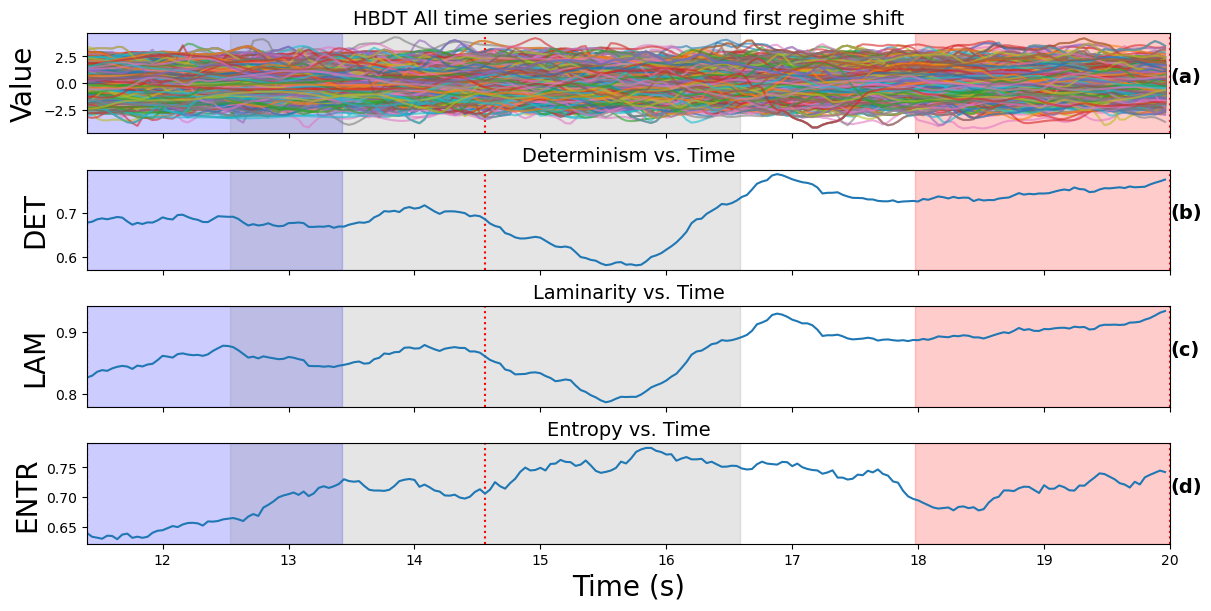

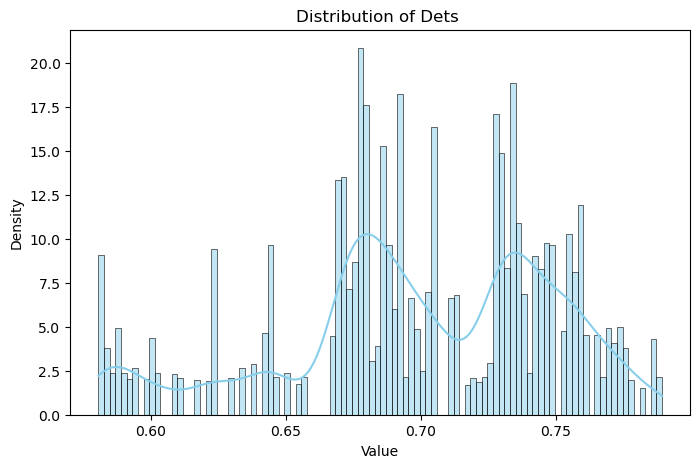

0.5912243841993987 0.7694554895417279


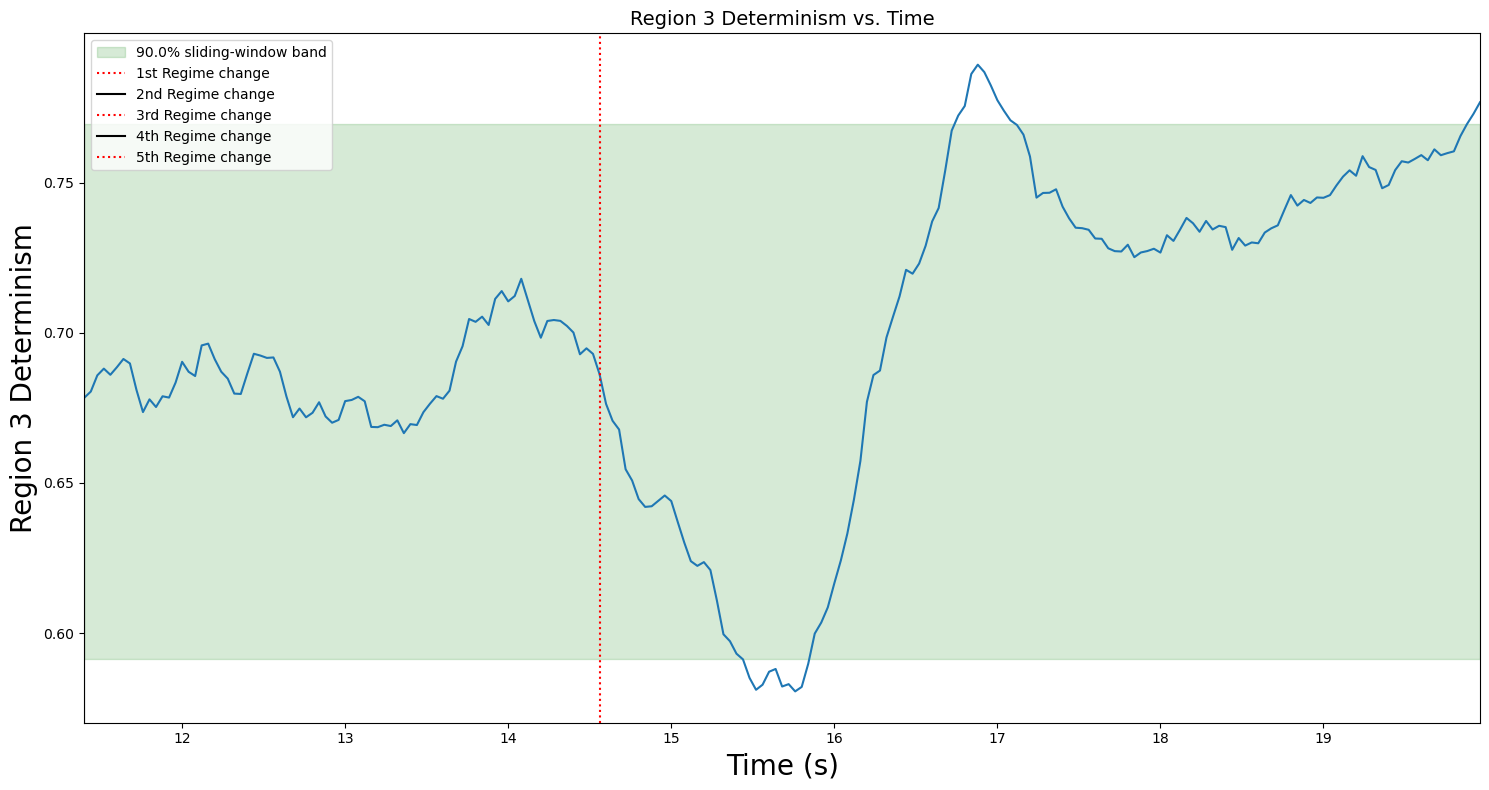

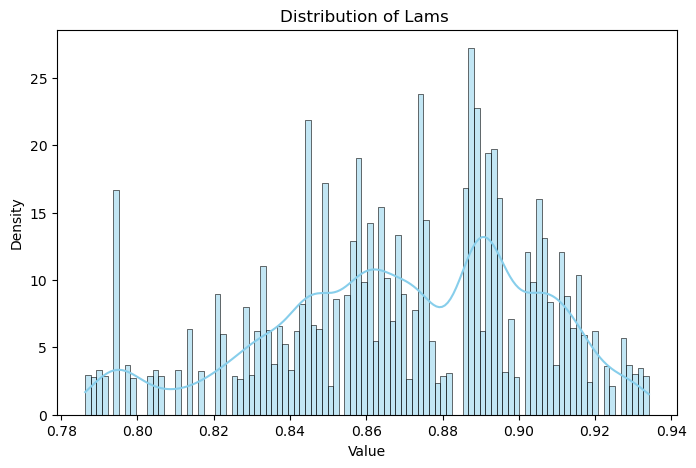

0.7988158965932148 0.9175000657459144


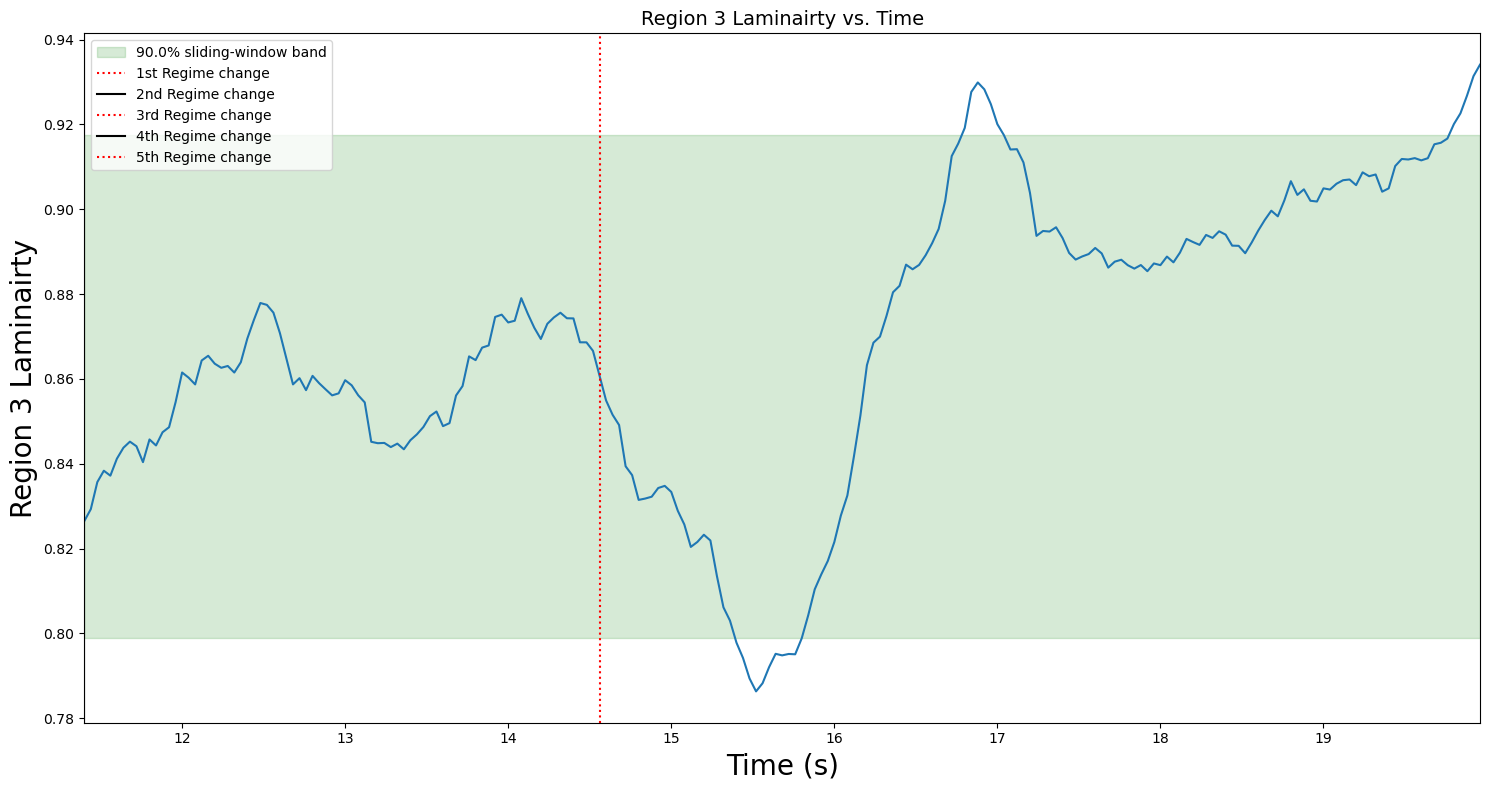

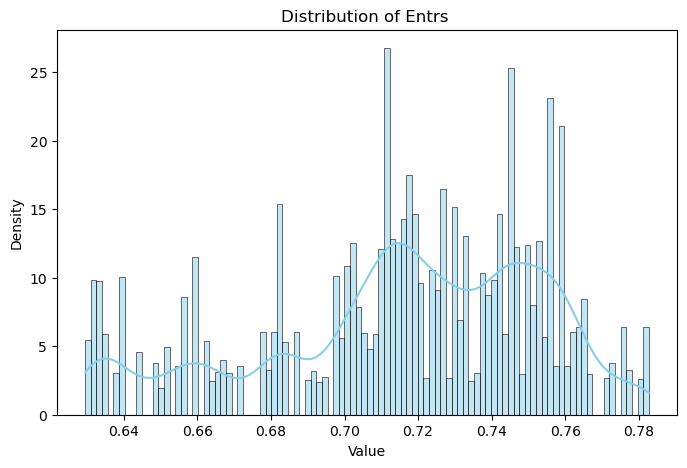

0.6371726852134907 0.7648883929326983


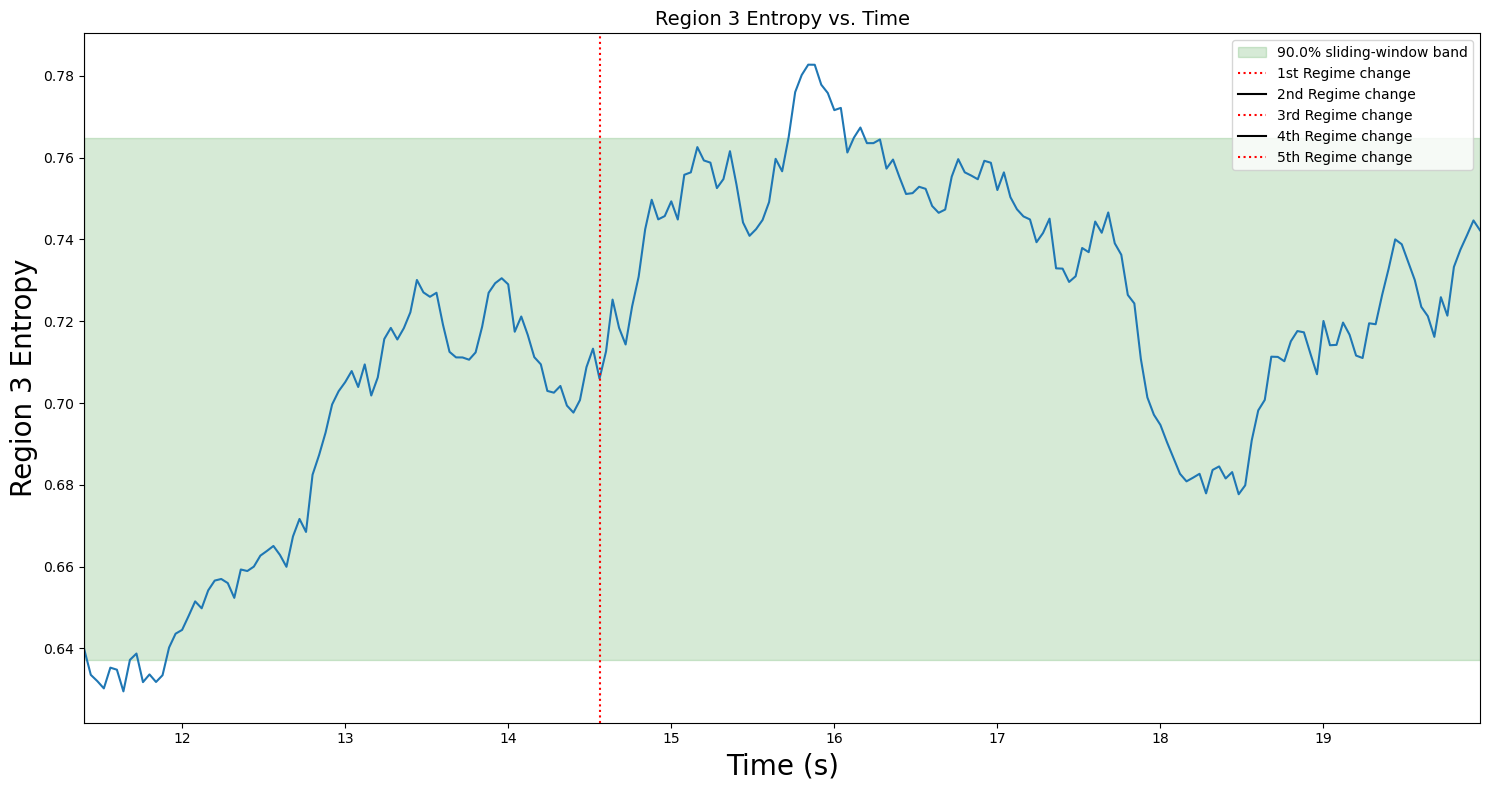

In [21]:
t1 = 11.4
t2 = 20
Change_one_DETS = DETS[int((t1/dt) - one_side): int((t2/dt) - one_side) ]
Change_one_LAMS = LAMS[int((t1/dt) - one_side): int((t2/dt) - one_side)]
Change_one_ENTRS = ENTRS[int((t1/dt) - one_side): int((t2/dt) - one_side)]
Change_one_times = times[int((t1/dt) - one_side): int((t2/dt) - one_side)]
Change_one_real_times = dt * Change_one_times
length = len(Change_one_DETS)
change_one_X = X.T[int((t1/dt)) : int((t2/dt))].T
real_times = Change_one_times * dt
total_time = change_one_X.shape[1] * dt
time_axis = t1+np.arange(change_one_X.shape[1]) * dt
regime_times = [14.56]
regime_kwargs = dict(color='red', linestyle='dotted')
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
i = 0 
colors = ['green', 'blue', 'gray', 'red', 'yellow']
for ax in axes:
    for t_real in regime_times_real:
        ax.axvline(t_real, **regime_kwargs)
        ax.axvspan(t_real - window_real/2, t_real + window_real/2, color=colors[i], alpha=0.2)
        i = (i+1)%5
        

labels = ['(a)', '(b)', '(c)', '(d)']

for row in change_one_X:
    axes[0].plot(real_times, row, alpha=0.6)
axes[0].set_ylabel('Value', fontsize=20)
axes[0].set_title('HBDT All time series region one around first regime shift', fontsize=14)
for t in regime_times:
    axes[0].axvline(t, **regime_kwargs)
axes[0].text(1, 0.51, labels[0], transform=axes[0].transAxes,
             fontsize=14, fontweight='bold')

axes[1].plot(Change_one_real_times, Change_one_DETS)
axes[1].set_ylabel('DET', fontsize=20)
axes[1].set_title('Determinism vs. Time', fontsize=14)
for t in regime_times:
    axes[1].axvline(t, **regime_kwargs)
axes[1].text(1, 0.51, labels[1], transform=axes[1].transAxes,
             fontsize=14, fontweight='bold')

axes[2].plot(Change_one_real_times, Change_one_LAMS)
axes[2].set_ylabel('LAM', fontsize=20)
axes[2].set_title('Laminarity vs. Time', fontsize=14)
for t in regime_times:
    axes[2].axvline(t, **regime_kwargs)
axes[2].text(1, 0.51, labels[2], transform=axes[2].transAxes,
             fontsize=14, fontweight='bold')

axes[3].plot(Change_one_real_times, Change_one_ENTRS)
axes[3].set_ylabel('ENTR', fontsize=20)
axes[3].set_title('Entropy vs. Time', fontsize=14)
for t in regime_times:
    axes[3].axvline(t, **regime_kwargs)
axes[3].text(1,0.51, labels[3], transform=axes[3].transAxes,
             fontsize=14, fontweight='bold')

axes[3].set_xlabel('Time (s)', fontsize=20)
axes[3].set_xlim(t1, t2)

plt.show()


sampled_dets, sampled_lams, sampled_entr = get_metrics(Change_one_DETS,Change_one_LAMS,Change_one_ENTRS,10000)

alpha=0.1
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
plotting(Change_one_DETS, 'Region 3 Determinism', lo,hi, alpha*100,Change_one_real_times)
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
plotting(Change_one_LAMS, 'Region 3 Laminairty', lo,hi, alpha*100,Change_one_real_times)
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')
plotting(Change_one_ENTRS, 'Region 3 Entropy', lo,hi, alpha*100,Change_one_real_times)

(2187, 386)
386
[ 0.    0.04  0.08  0.12  0.16  0.2   0.24  0.28  0.32  0.36  0.4   0.44
  0.48  0.52  0.56  0.6   0.64  0.68  0.72  0.76  0.8   0.84  0.88  0.92
  0.96  1.    1.04  1.08  1.12  1.16  1.2   1.24  1.28  1.32  1.36  1.4
  1.44  1.48  1.52  1.56  1.6   1.64  1.68  1.72  1.76  1.8   1.84  1.88
  1.92  1.96  2.    2.04  2.08  2.12  2.16  2.2   2.24  2.28  2.32  2.36
  2.4   2.44  2.48  2.52  2.56  2.6   2.64  2.68  2.72  2.76  2.8   2.84
  2.88  2.92  2.96  3.    3.04  3.08  3.12  3.16  3.2   3.24  3.28  3.32
  3.36  3.4   3.44  3.48  3.52  3.56  3.6   3.64  3.68  3.72  3.76  3.8
  3.84  3.88  3.92  3.96  4.    4.04  4.08  4.12  4.16  4.2   4.24  4.28
  4.32  4.36  4.4   4.44  4.48  4.52  4.56  4.6   4.64  4.68  4.72  4.76
  4.8   4.84  4.88  4.92  4.96  5.    5.04  5.08  5.12  5.16  5.2   5.24
  5.28  5.32  5.36  5.4   5.44  5.48  5.52  5.56  5.6   5.64  5.68  5.72
  5.76  5.8   5.84  5.88  5.92  5.96  6.    6.04  6.08  6.12  6.16  6.2
  6.24  6.28  6.32  6.36  6.4   6.44  

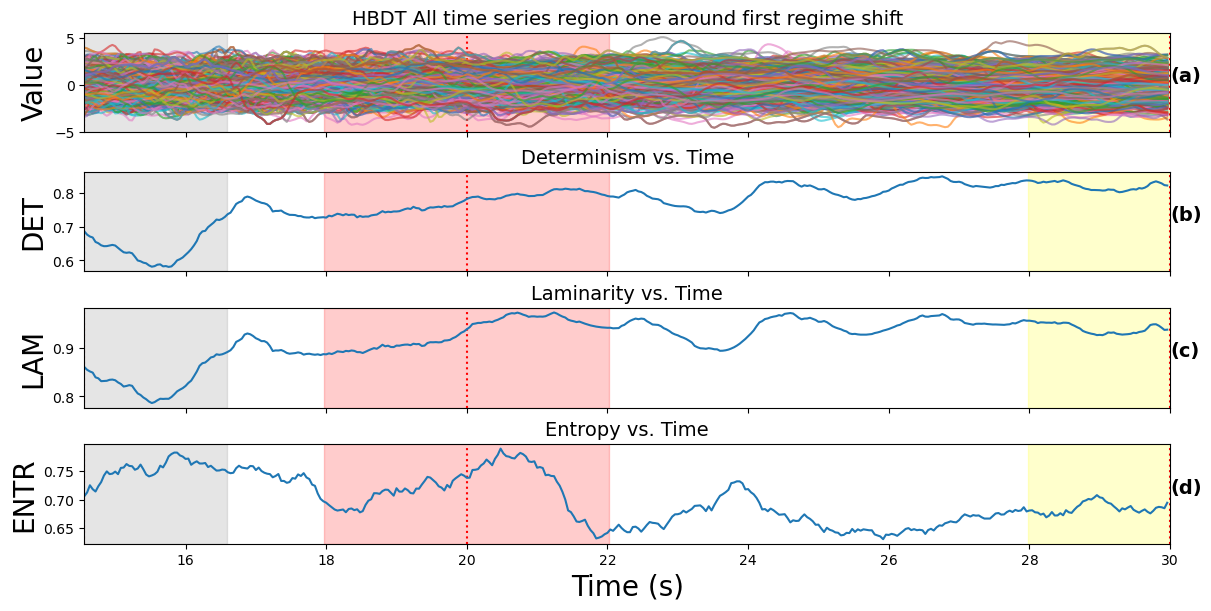

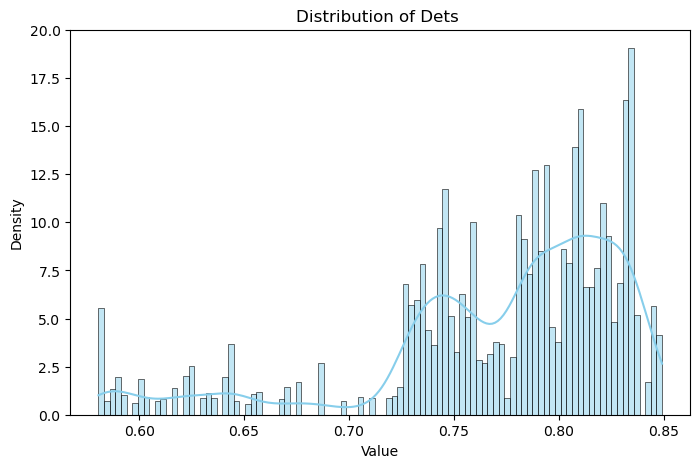

0.6223660584678142 0.8354992410986503


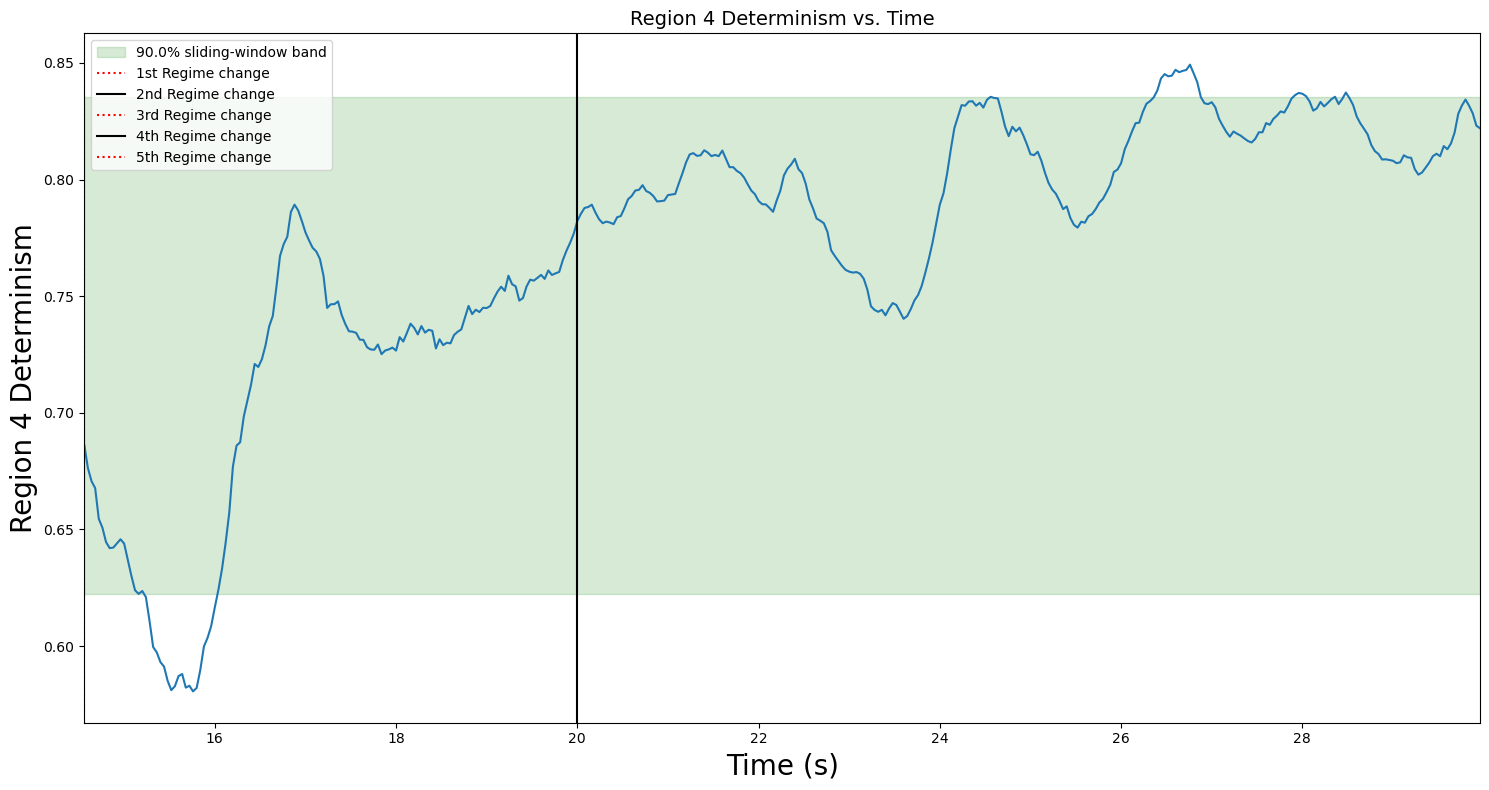

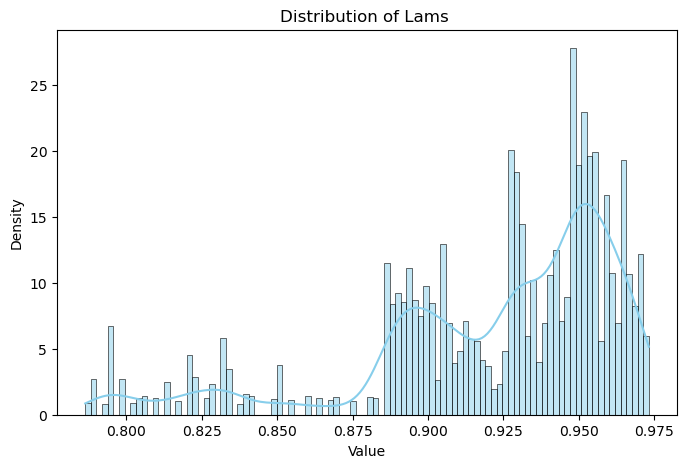

0.821547722359271 0.9671118291805426


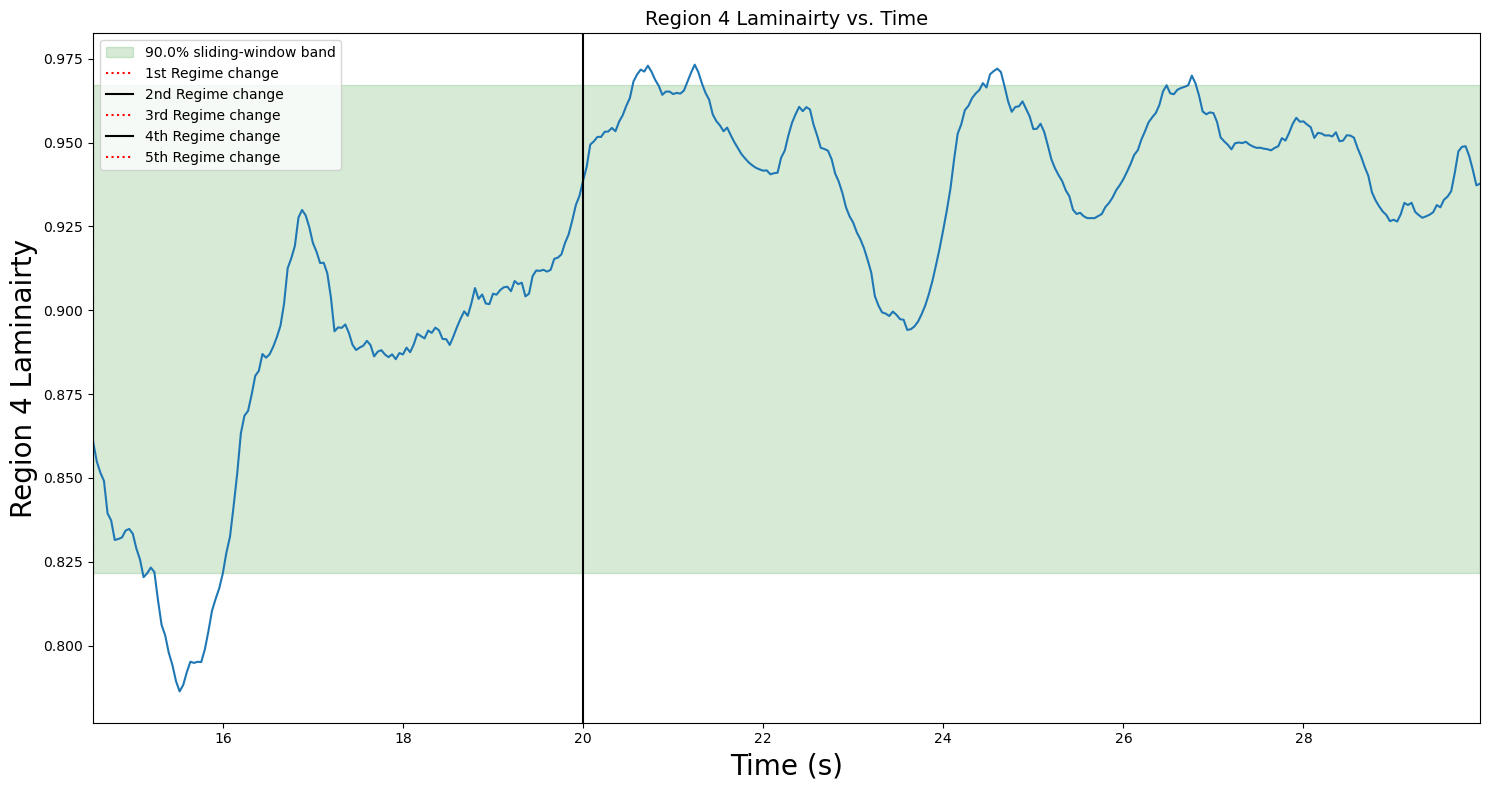

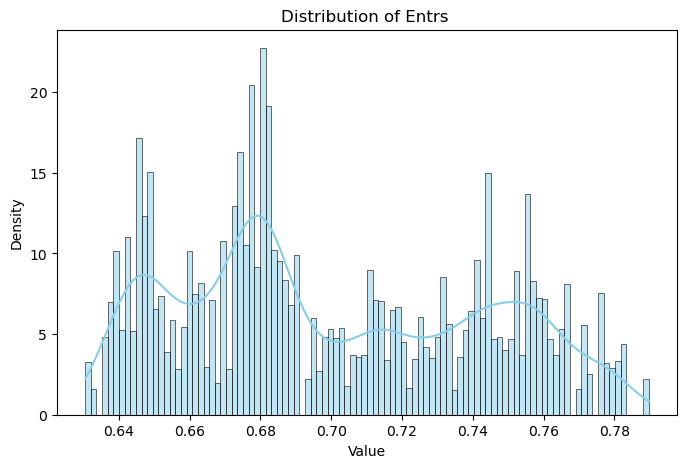

0.6412379978326276 0.7716356057250521


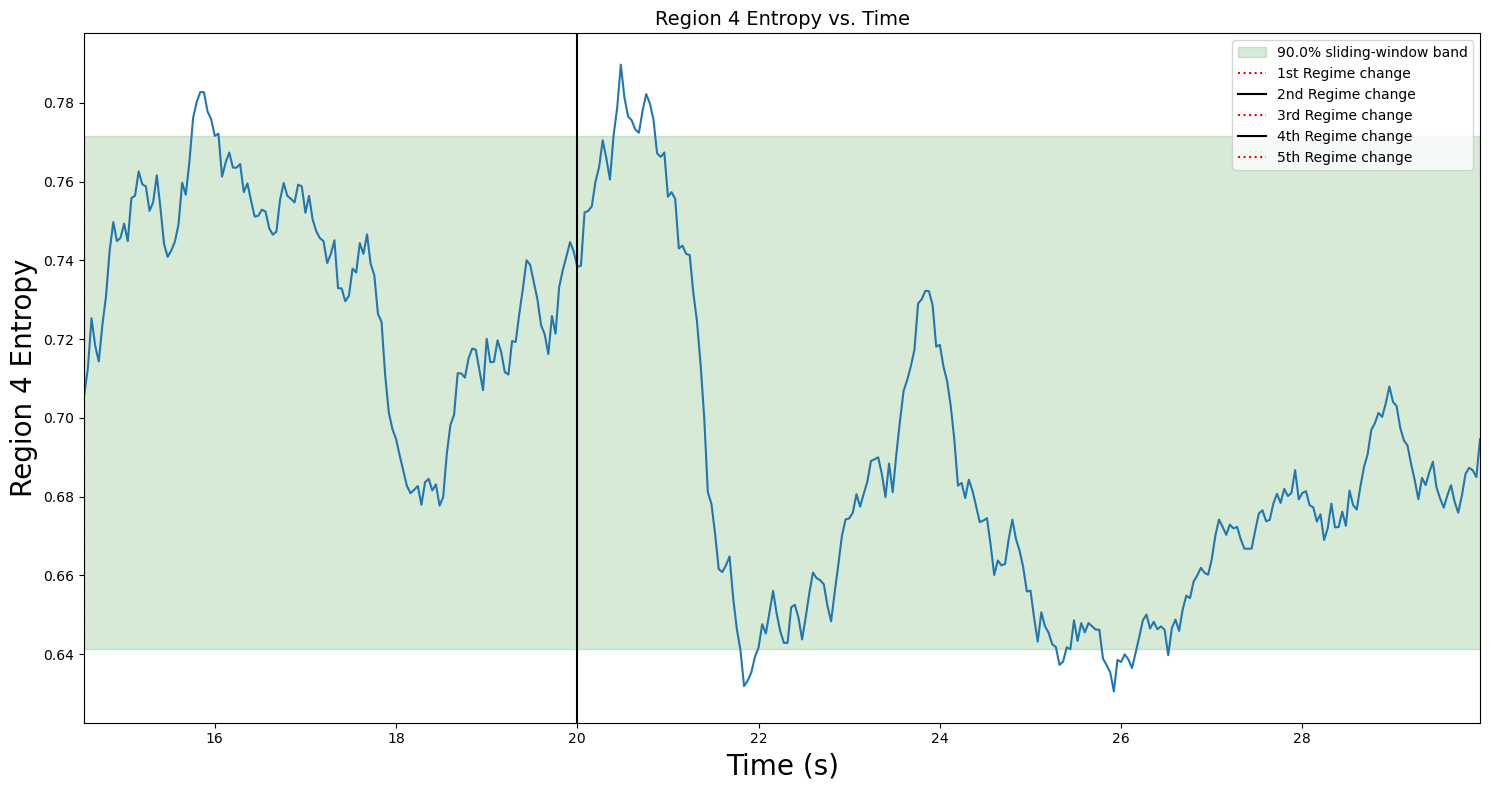

In [22]:
t1 = 14.56
t2 = 30
Change_one_DETS = DETS[int((t1/dt) - one_side): int((t2/dt) - one_side) ]
Change_one_LAMS = LAMS[int((t1/dt) - one_side): int((t2/dt) - one_side)]
Change_one_ENTRS = ENTRS[int((t1/dt) - one_side): int((t2/dt) - one_side)]
Change_one_times = times[int((t1/dt) - one_side): int((t2/dt) - one_side)]
Change_one_real_times = dt * Change_one_times
length = len(Change_one_DETS)
change_one_X = X.T[int((t1/dt)) : int((t2/dt))].T
real_times = Change_one_times * dt
total_time = change_one_X.shape[1] * dt
time_axis = np.arange(change_one_X.shape[1]) * dt
regime_times = [20]
regime_kwargs = dict(color='red', linestyle='dotted')
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
i = 0 
colors = ['green', 'blue', 'gray', 'red', 'yellow']
for ax in axes:
    for t_real in regime_times_real:
        ax.axvline(t_real, **regime_kwargs)
        ax.axvspan(t_real - window_real/2, t_real + window_real/2, color=colors[i], alpha=0.2)
        i = (i+1)%5
        

labels = ['(a)', '(b)', '(c)', '(d)']

for row in change_one_X:
    axes[0].plot(real_times, row, alpha=0.6)
axes[0].set_ylabel('Value', fontsize=20)
axes[0].set_title('HBDT All time series region one around first regime shift', fontsize=14)
for t in regime_times:
    axes[0].axvline(t, **regime_kwargs)
axes[0].text(1, 0.51, labels[0], transform=axes[0].transAxes,
             fontsize=14, fontweight='bold')

axes[1].plot(Change_one_real_times, Change_one_DETS)
axes[1].set_ylabel('DET', fontsize=20)
axes[1].set_title('Determinism vs. Time', fontsize=14)
for t in regime_times:
    axes[1].axvline(t, **regime_kwargs)
axes[1].text(1, 0.51, labels[1], transform=axes[1].transAxes,
             fontsize=14, fontweight='bold')

axes[2].plot(Change_one_real_times, Change_one_LAMS)
axes[2].set_ylabel('LAM', fontsize=20)
axes[2].set_title('Laminarity vs. Time', fontsize=14)
for t in regime_times:
    axes[2].axvline(t, **regime_kwargs)
axes[2].text(1, 0.51, labels[2], transform=axes[2].transAxes,
             fontsize=14, fontweight='bold')

axes[3].plot(Change_one_real_times, Change_one_ENTRS)
axes[3].set_ylabel('ENTR', fontsize=20)
axes[3].set_title('Entropy vs. Time', fontsize=14)
for t in regime_times:
    axes[3].axvline(t, **regime_kwargs)
axes[3].text(1,0.51, labels[3], transform=axes[3].transAxes,
             fontsize=14, fontweight='bold')

axes[3].set_xlabel('Time (s)', fontsize=20)
axes[3].set_xlim(t1, t2)

plt.show()


sampled_dets, sampled_lams, sampled_entr = get_metrics(Change_one_DETS,Change_one_LAMS,Change_one_ENTRS,10000)

alpha=0.1
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
plotting(Change_one_DETS, 'Region 4 Determinism', lo,hi, alpha*100,Change_one_real_times)
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
plotting(Change_one_LAMS, 'Region 4 Laminairty', lo,hi, alpha*100,Change_one_real_times)
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')
plotting(Change_one_ENTRS, 'Region 4 Entropy', lo,hi, alpha*100,Change_one_real_times)

(2187, 512)
(462,)
[20.   20.04 20.08 20.12 20.16 20.2  20.24 20.28 20.32 20.36 20.4  20.44
 20.48 20.52 20.56 20.6  20.64 20.68 20.72 20.76 20.8  20.84 20.88 20.92
 20.96 21.   21.04 21.08 21.12 21.16 21.2  21.24 21.28 21.32 21.36 21.4
 21.44 21.48 21.52 21.56 21.6  21.64 21.68 21.72 21.76 21.8  21.84 21.88
 21.92 21.96 22.   22.04 22.08 22.12 22.16 22.2  22.24 22.28 22.32 22.36
 22.4  22.44 22.48 22.52 22.56 22.6  22.64 22.68 22.72 22.76 22.8  22.84
 22.88 22.92 22.96 23.   23.04 23.08 23.12 23.16 23.2  23.24 23.28 23.32
 23.36 23.4  23.44 23.48 23.52 23.56 23.6  23.64 23.68 23.72 23.76 23.8
 23.84 23.88 23.92 23.96 24.   24.04 24.08 24.12 24.16 24.2  24.24 24.28
 24.32 24.36 24.4  24.44 24.48 24.52 24.56 24.6  24.64 24.68 24.72 24.76
 24.8  24.84 24.88 24.92 24.96 25.   25.04 25.08 25.12 25.16 25.2  25.24
 25.28 25.32 25.36 25.4  25.44 25.48 25.52 25.56 25.6  25.64 25.68 25.72
 25.76 25.8  25.84 25.88 25.92 25.96 26.   26.04 26.08 26.12 26.16 26.2
 26.24 26.28 26.32 26.36 26.4  26.4

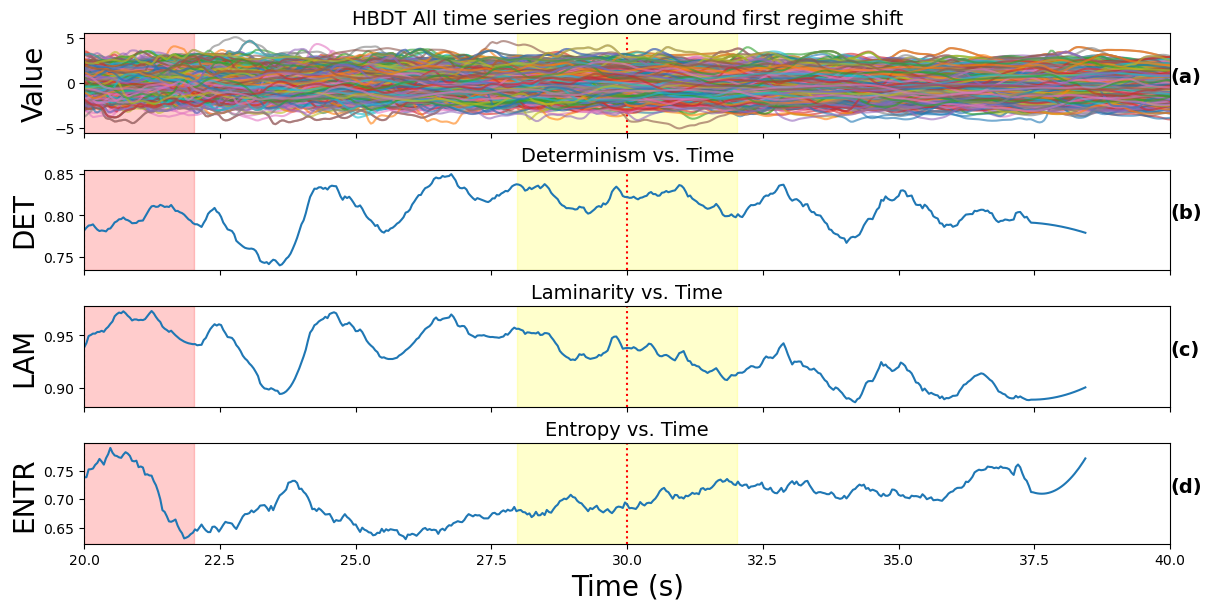

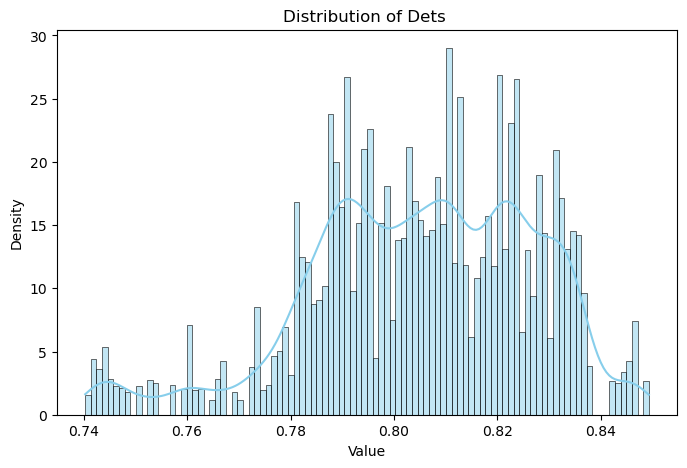

0.7630195803116492 0.8353653771780547


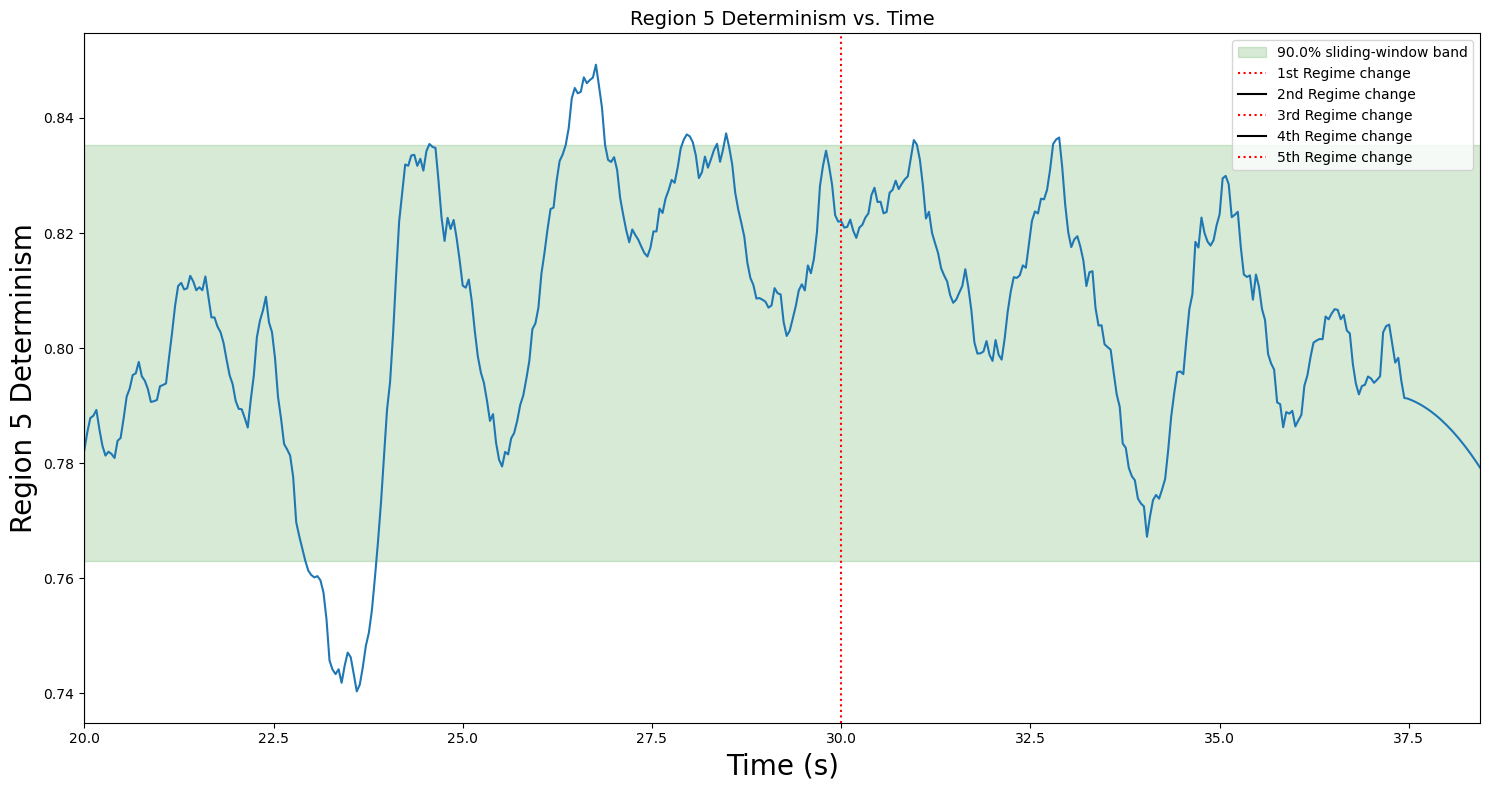

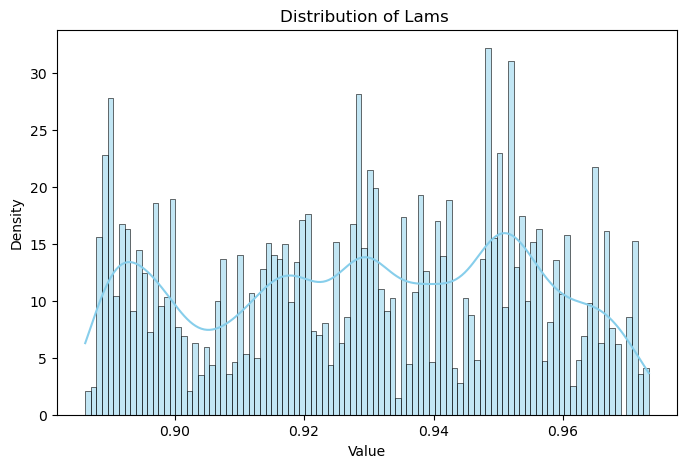

0.8901135599516171 0.9664488924325565


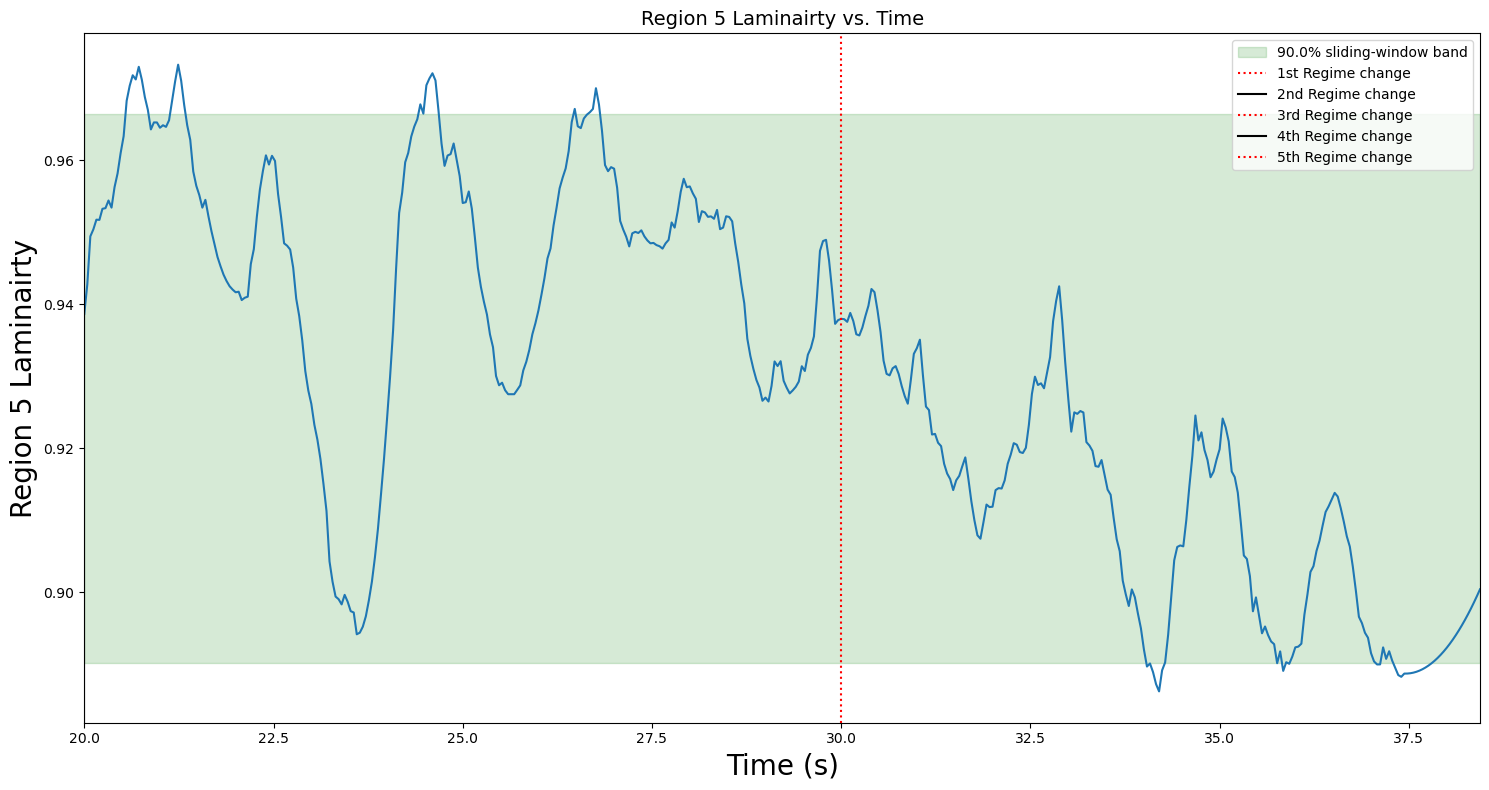

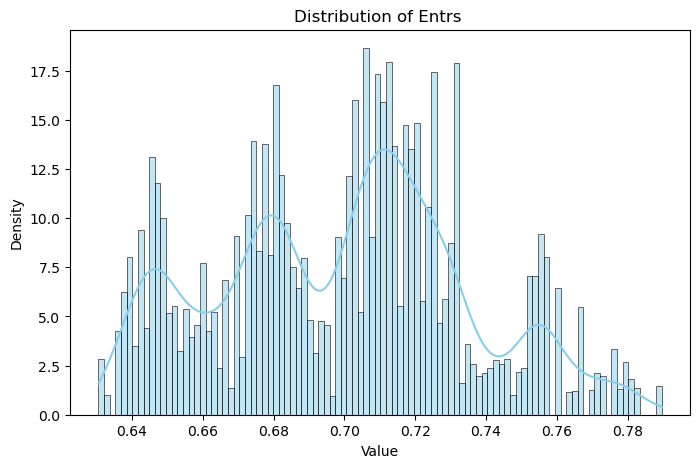

0.6428095275566672 0.7597146696883336


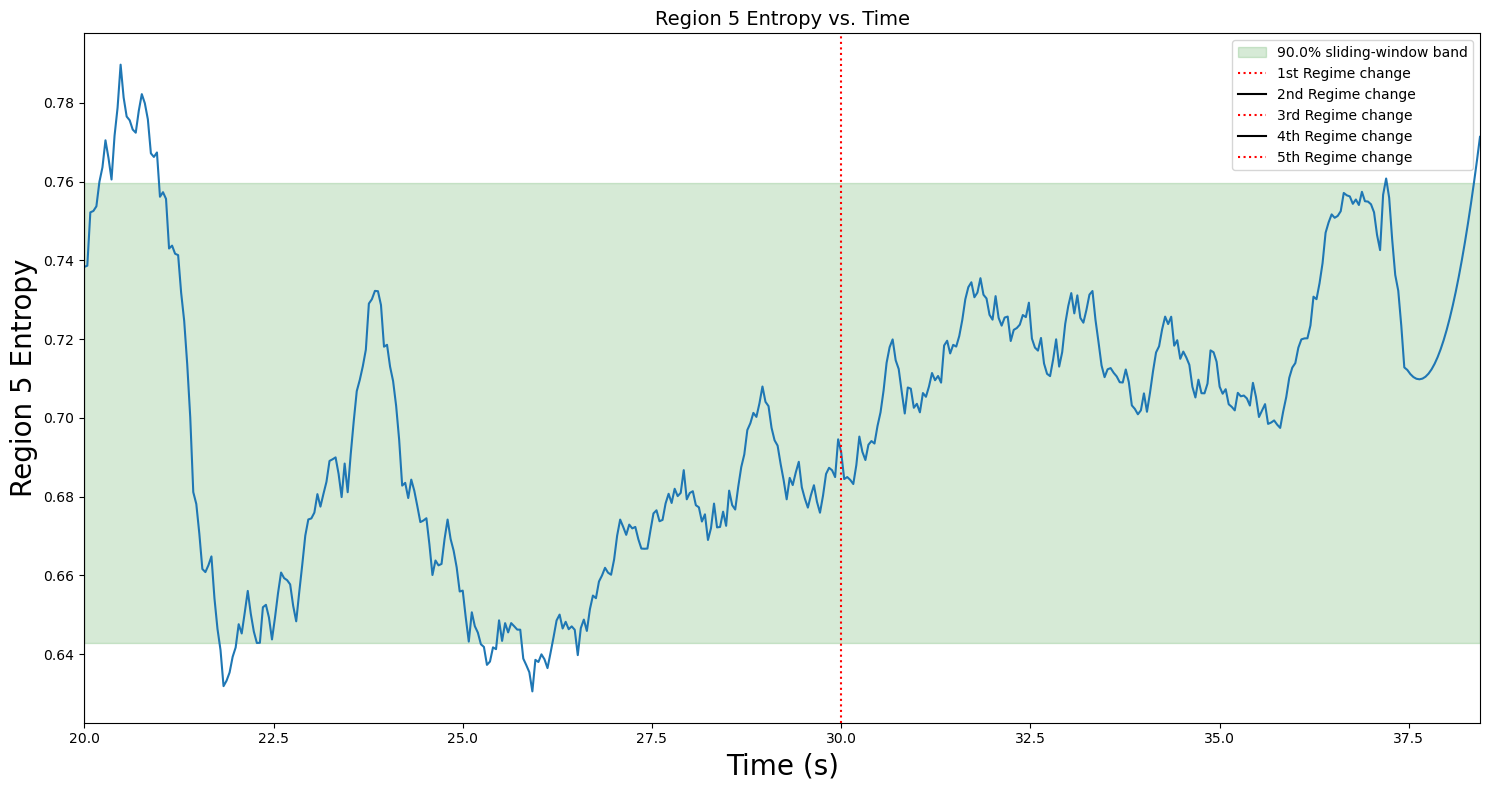

In [33]:
t1 = 20
t2 = 40
Change_one_DETS = DETS[int((t1/dt) - one_side):]
Change_one_LAMS = LAMS[int((t1/dt) - one_side):]
Change_one_ENTRS = ENTRS[int((t1/dt) - one_side):]
Change_one_times = times[int((t1/dt) - one_side):]
Change_one_real_times = dt * Change_one_times
length = len(Change_one_DETS)
change_one_X = X.T[int((t1/dt)):].T
real_times = Change_one_times * dt
total_time = change_one_X.shape[1] * dt
time_axis = 20+ np.arange(change_one_X.shape[1]) * dt
regime_times = [30]
regime_kwargs = dict(color='red', linestyle='dotted')
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
i = 0 
colors = ['green', 'blue', 'gray', 'red', 'yellow']
for ax in axes:
    for t_real in regime_times_real:
        ax.axvline(t_real, **regime_kwargs)
        ax.axvspan(t_real - window_real/2, t_real + window_real/2, color=colors[i], alpha=0.2)
        i = (i+1)%5
        

labels = ['(a)', '(b)', '(c)', '(d)']

 
for row in change_one_X:
    axes[0].plot(time_axis, row, alpha=0.6)
axes[0].set_ylabel('Value', fontsize=20)
axes[0].set_title('HBDT All time series region one around first regime shift', fontsize=14)
for t in regime_times:
    axes[0].axvline(t, **regime_kwargs)
axes[0].text(1, 0.51, labels[0], transform=axes[0].transAxes,
             fontsize=14, fontweight='bold')

axes[1].plot(Change_one_real_times, Change_one_DETS)
axes[1].set_ylabel('DET', fontsize=20)
axes[1].set_title('Determinism vs. Time', fontsize=14)
for t in regime_times:
    axes[1].axvline(t, **regime_kwargs)
axes[1].text(1, 0.51, labels[1], transform=axes[1].transAxes,
             fontsize=14, fontweight='bold')

axes[2].plot(Change_one_real_times, Change_one_LAMS)
axes[2].set_ylabel('LAM', fontsize=20)
axes[2].set_title('Laminarity vs. Time', fontsize=14)
for t in regime_times:
    axes[2].axvline(t, **regime_kwargs)
axes[2].text(1, 0.51, labels[2], transform=axes[2].transAxes,
             fontsize=14, fontweight='bold')

axes[3].plot(Change_one_real_times, Change_one_ENTRS)
axes[3].set_ylabel('ENTR', fontsize=20)
axes[3].set_title('Entropy vs. Time', fontsize=14)
for t in regime_times:
    axes[3].axvline(t, **regime_kwargs)
axes[3].text(1,0.51, labels[3], transform=axes[3].transAxes,
             fontsize=14, fontweight='bold')

axes[3].set_xlabel('Time (s)', fontsize=20)
axes[3].set_xlim(t1, t2)

plt.show()


sampled_dets, sampled_lams, sampled_entr = get_metrics(Change_one_DETS,Change_one_LAMS,Change_one_ENTRS,10000)

alpha=0.1
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
plotting(Change_one_DETS, 'Region 5 Determinism', lo,hi, alpha*100,Change_one_real_times)
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
plotting(Change_one_LAMS, 'Region 5 Laminairty', lo,hi, alpha*100,Change_one_real_times)
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')
plotting(Change_one_ENTRS, 'Region 5 Entropy', lo,hi, alpha*100,Change_one_real_times)